## Phase 1: Predicting Drug resistance (y = Drugs, X = Mutations)

In [542]:
#Import packages
import pandas as pd

#Read in data
df = pd.read_csv("geno-pheno.dataset.tsv", sep = "\t")

df.head()

/tmp/ipykernel_8193/2676976629.py:5: DtypeWarning: Columns (0: AZT, 1: DDCFoldMatch, 2: TAFFoldMatch) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("geno-pheno.dataset.tsv", sep = "\t")


,RefID,IsolateID,IsolateName,Species,Type,PtID,Method,3TC,3TCFoldMatch,ABC,...,P291,P292,P293,P294,P295,P296,P297,P298,P299,P300
0,756,9918,CA9918,HIV1,Clinical,1391.0,PhenoSense,200.0,>,4.6,...,-,-,-,-,-,-,-,-,-,-
1,756,3832,CA3832,HIV1,Clinical,1433.0,PhenoSense,200.0,>,8.8,...,-,-,.,.,.,.,.,.,.,.
2,756,10464,CA10464,HIV1,Clinical,634.0,PhenoSense,200.0,>,14.0,...,.,.,.,.,.,.,.,.,.,.
3,756,9928,CA9928,HIV1,Clinical,637.0,PhenoSense,200.0,>,6.7,...,-,-,V,-,-,-,K,-,-,-
4,756,4372,CA4372,HIV1,Clinical,1274.0,PhenoSense,200.0,>,7.1,...,-,-,V,-,-,-,-,-,-,-


In [543]:
##Cleaning the data set
df2 = df.copy()
df2.head()
df2.shape

(2505, 335)

In [544]:
# Dimensionality of data
df2.shape

(2505, 335)

### Exploratory data analysis

In [545]:
#DRop columns we don't need in the training
df2 = df.drop(columns = ["RefID","Species","Type", "Method", "NNRTIDRMs", 'CompleteMutationListAvailable', 'Author','NonDRMs', 'Author','RefYear', 'MedlineID', 'Title',  'PtID'])
df2.head(n = 300)
df2.shape

#Remove Protease positions

df2 = df2.loc[:, ~df2.columns.str.match(r"^P\d+$")]
df2.head()
df2.shape

(2505, 23)

In [546]:
# Explore the data
#df2.describe()

#df2.info()

df2.columns

df2.shape

(2505, 23)

In [547]:
# Find reverse transcriptase columns
[col for col in df2.columns if "RT" in col.upper()]

['NRTIDRMs']

In [548]:
#Check which columns retained
df2.columns

Index(['IsolateID', 'IsolateName', '3TC', '3TCFoldMatch', 'ABC',
       'ABCFoldMatch', 'AZT', 'AZTFoldMatch', 'D4T', 'D4TFoldMatch', 'DDC',
       'DDCFoldMatch', 'DDI', 'DDIFoldMatch', 'FTC', 'FTCFoldMatch', 'ISL',
       'ISLFoldMatch', 'TAF', 'TAFFoldMatch', 'TDF', 'TDFFoldMatch',
       'NRTIDRMs'],
      dtype='str')

In [549]:
#View data 
df2.head()

,IsolateID,IsolateName,3TC,3TCFoldMatch,ABC,ABCFoldMatch,AZT,AZTFoldMatch,D4T,D4TFoldMatch,...,DDIFoldMatch,FTC,FTCFoldMatch,ISL,ISLFoldMatch,TAF,TAFFoldMatch,TDF,TDFFoldMatch,NRTIDRMs
0,9918,CA9918,200.0,>,4.6,=,0.6,=,1.0,=,...,=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M184V
1,3832,CA3832,200.0,>,8.8,=,3.2,=,1.9,=,...,=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"M41L, L74LV, M184V, L210W, T215Y"
2,10464,CA10464,200.0,>,14.0,=,307,=,6.4,=,...,=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"M41L, E44A, D67N, T69D, M184V, L210W, T215Y"
3,9928,CA9928,200.0,>,6.7,=,6.5,=,1.6,=,...,=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"M41L, M184V, T215Y"
4,4372,CA4372,200.0,>,7.1,=,0.8,=,1.3,=,...,=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"D67N, K70G, M184V, T215F, K219Q"


In [550]:
#Identifying unique mutations in the dataset

df2.dtypes

IsolateID         int64
IsolateName         str
3TC             float64
3TCFoldMatch        str
ABC             float64
ABCFoldMatch        str
AZT              object
AZTFoldMatch        str
D4T             float64
D4TFoldMatch        str
DDC             float64
DDCFoldMatch        str
DDI             float64
DDIFoldMatch        str
FTC             float64
FTCFoldMatch        str
ISL             float64
ISLFoldMatch        str
TAF             float64
TAFFoldMatch        str
TDF             float64
TDFFoldMatch        str
NRTIDRMs            str
dtype: object

In [551]:
# Number of duplicate IsolateIDs
print("Duplicate IsolateIDs:", df2["IsolateID"].duplicated().sum())


Duplicate IsolateIDs: 0


In [552]:
# Abstract drugs
missing = (df2.isnull().sum().to_frame(name="Missing"))

missing["Percent"] = round(missing["Missing"] / len(df2) * 100, 2)

missing.sort_values("Percent", ascending=False)

,Missing,Percent
ISLFoldMatch,2473,98.72
ISL,2473,98.72
TAFFoldMatch,2409,96.17
TAF,2409,96.17
DDCFoldMatch,2036,81.28
DDC,2003,79.96
FTCFoldMatch,1948,77.76
FTC,1948,77.76
NRTIDRMs,512,20.44
TDF,493,19.68


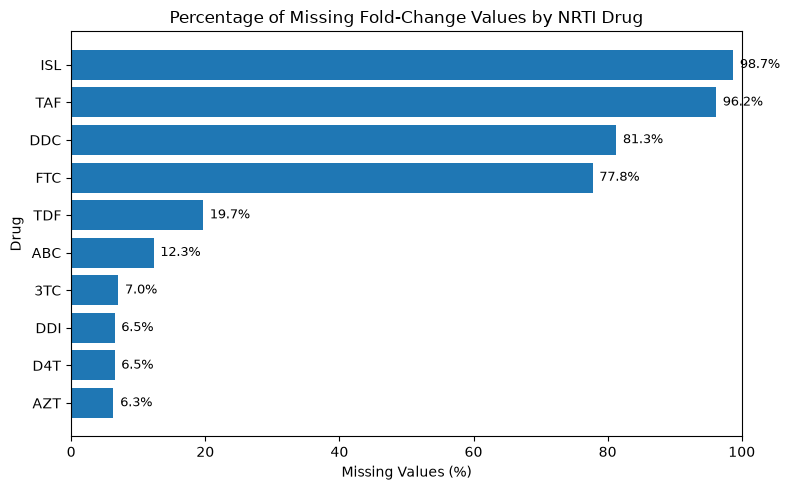

In [553]:
import pandas as pd
import matplotlib.pyplot as plt

# Missingness of fold-change columns only
missing_fc = pd.DataFrame({
    "Drug": ["ISL", "TAF", "DDC", "FTC", "TDF", "ABC", "3TC", "D4T", "DDI", "AZT"],
    "Missing (%)": [98.72, 96.17, 81.28, 77.76, 19.68, 12.30, 7.03, 6.47, 6.47, 6.31]
})

# Sort from highest to lowest missingness
missing_fc = missing_fc.sort_values("Missing (%)", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(missing_fc["Drug"], missing_fc["Missing (%)"])
plt.xlabel("Missing Values (%)")
plt.ylabel("Drug")
plt.title("Percentage of Missing Fold-Change Values by NRTI Drug")
plt.xlim(0, 100)

# Add value labels
for i, v in enumerate(missing_fc["Missing (%)"]):
    plt.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("missing_foldchange_barplot.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [554]:
#Measure completeness of Drug data
drug_cols = ["3TC", "ABC", "AZT", "D4T", "DDC", "DDI", "FTC", "ISL", "TAF", "TDF"]

available = df2[drug_cols].notna().sum().sort_values(ascending=False)

print(available)

AZT    2381
D4T    2377
DDI    2377
3TC    2359
ABC    2231
TDF    2012
FTC     557
DDC     502
TAF      96
ISL      32
dtype: int64


In [555]:
#DRop columns we don't need in the training
df_clean = df2.drop(columns = ["3TCFoldMatch", "ABCFoldMatch", "AZTFoldMatch", "D4TFoldMatch", "DDCFoldMatch", "DDIFoldMatch", "FTCFoldMatch", "ISLFoldMatch", "TAFFoldMatch", "TDFFoldMatch"])
df_clean.head(n = 300)

#Drop DRugs with < 1000 complete cells
df_clean = df_clean.drop(columns = ["DDC", "FTC", "ISL", "TAF"])
df_clean.head(n=30)

,IsolateID,IsolateName,3TC,ABC,AZT,D4T,DDI,TDF,NRTIDRMs
0,9918,CA9918,200.0,4.6,0.6,1.0,1.6,NaN,M184V
1,3832,CA3832,200.0,8.8,3.2,1.9,2.1,NaN,"M41L, L74LV, M184V, L210W, T215Y"
2,10464,CA10464,200.0,14.0,307,6.4,2.7,NaN,"M41L, E44A, D67N, T69D, M184V, L210W, T215Y"
3,9928,CA9928,200.0,6.7,6.5,1.6,1.4,NaN,"M41L, M184V, T215Y"
4,4372,CA4372,200.0,7.1,0.8,1.3,1.9,NaN,"D67N, K70G, M184V, T215F, K219Q"
5,4391,CA4391,200.0,5.9,1.9,1.3,1.7,NaN,"D67N, K70R, M184V, K219Q"
6,9912,CA9912,200.0,18.0,100,11.0,3.5,NaN,"E40F, M41L, D67N, V75M, M184V, L210W, T215Y, K..."
7,9945,CA9945,200.0,29.0,726,10.0,4.1,NaN,"M41L, D67N, T69D, K70R, V75M, M184V, T215F, K219W"
8,9916,CA9916,200.0,7.7,7.9,2.3,1.8,NaN,"D67N, K70R, M184V, K219Q"
9,9944,CA9944,200.0,8.5,14,1.7,1.7,NaN,"M41L, M184V, L210W, T215Y"


In [556]:
#Data types for df_clean
print(df_clean.dtypes)

IsolateID        int64
IsolateName        str
3TC            float64
ABC            float64
AZT             object
D4T            float64
DDI            float64
TDF            float64
NRTIDRMs           str
dtype: object


In [557]:
# Remove Isolates that lack NRTIDRMs
#df_clean.dropna(subset = ["NRTIDRMs"], inplace= True)
#df_clean

#Replacing isolates that lack NRTIDRMs with empty strings
df_clean["NRTIDRMs"] = df_clean["NRTIDRMs"].fillna("")
df_clean.tail(n = 30)

,IsolateID,IsolateName,3TC,ABC,AZT,D4T,DDI,TDF,NRTIDRMs
2475,743974,DOR-clinical-resistance-7,100.0,2.9,0.5,0.8,1.6,0.8,M184V
2476,692618,ISO3,1.2,0.8,1.7,0.9,0.9,1.2,
2477,692622,ISO7,0.9,1.5,1.5,1.4,1.6,1.8,
2478,692619,ISO4,0.4,0.7,0.3,0.6,0.7,0.3,
2479,743968,DOR-clinical-resistance-1,100.0,2.7,0.1,0.7,1.2,0.5,M184V
2480,743969,DOR-clinical-resistance-2,100.0,3.2,0.1,0.6,1.2,0.6,M184V
2481,692621,ISO6,0.4,0.7,0.8,1.0,0.1,0.8,
2482,743971,DOR-clinical-resistance-4,3.1,0.7,0.2,0.7,1.0,0.3,
2483,692616,ISO1,0.4,1.7,0.3,1.3,1.1,1.5,
2484,743973,DOR-clinical-resistance-6,100.0,2.8,0.1,0.5,1.5,0.4,"K65R, M184V"


In [558]:
#Count Number of Isolates - Number reduced after pruning isolates lacking NRTI-DRMs
df_clean["IsolateID"].nunique()

2505

In [559]:
## Mutation List Generation
df_clean['Mutation_List'] = df_clean['NRTIDRMs'].apply(lambda s: [m.strip() for m in s.split(',') if m.strip()])
df_clean["Mutation_List"].head(n=30)
df_clean["Mutation_List"].tail(n = 30)


2475                                              [M184V]
2476                                                   []
2477                                                   []
2478                                                   []
2479                                              [M184V]
2480                                              [M184V]
2481                                                   []
2482                                                   []
2483                                                   []
2484                                        [K65R, M184V]
2485                                              [M184V]
2486                                               [K65R]
2487                                                   []
2488                                                   []
2489    [M41L, E44D, D67N, T69D, L74V, M184V, L210W, T...
2490                                                   []
2491                           [M41L, L74V, L210W, T215Y]
2492    [M41ML

In [560]:
#Save cleaned data 
# df_clean.to_csv("geno-pheno_clean.tsv", sep="\t", index=False)
# df_clean.head(n=30)
print(type(df_clean["Mutation_List"].iloc[0]))

<class 'list'>


### Calculating Mutation Frequencies

In [561]:
# Preparing for features (Mutations) Matrix generation 
df_clean[["IsolateName","NRTIDRMs", "Mutation_List"]].tail(30)

,IsolateName,NRTIDRMs,Mutation_List
2475,DOR-clinical-resistance-7,M184V,[M184V]
2476,ISO3,,[]
2477,ISO7,,[]
2478,ISO4,,[]
2479,DOR-clinical-resistance-1,M184V,[M184V]
2480,DOR-clinical-resistance-2,M184V,[M184V]
2481,ISO6,,[]
2482,DOR-clinical-resistance-4,,[]
2483,ISO1,,[]
2484,DOR-clinical-resistance-6,"K65R, M184V","[K65R, M184V]"


### Feature Selection

In [562]:
# Mutation frequency calculation
#Expanding comma-separated mutations into separate rows (Long Format)
df_mut_exploded = df_clean.explode('Mutation_List').dropna(subset=['Mutation_List'])
df_mut_exploded.head()

#Mutation Frequency Analysis
total_isolates = df_clean['IsolateID'].nunique()
global_frequencies = df_mut_exploded['Mutation_List'].value_counts().reset_index()
global_frequencies = global_frequencies[
    (global_frequencies['Mutation_List'] != "") 
]
global_frequencies.columns = ['Mutation_List', 'Absolute_Count']

global_frequencies. head(n = 30)

,Mutation_List,Absolute_Count
0,M184V,1153
1,M41L,999
2,T215Y,887
3,D67N,811
4,L210W,697
5,K70R,474
6,K219Q,364
7,T215F,259
8,T69D,241
9,E44D,211


In [563]:
#Check dimensionality
df_clean.dtypes

#Check empty
mut_empty = (df_clean["Mutation_List"].str.len() == 0).sum()
mut_empty


512

total_isolate

In [564]:
#Calculate proportionality of mutations
global_frequencies['Global_Frequency_%'] = (global_frequencies['Absolute_Count'] / (total_isolates - mut_empty))* 100
global_frequencies.head(30)


,Mutation_List,Absolute_Count,Global_Frequency_%
0,M184V,1153,57.852484
1,M41L,999,50.125439
2,T215Y,887,44.505770
3,D67N,811,40.692423
4,L210W,697,34.972403
5,K70R,474,23.783241
6,K219Q,364,18.263924
7,T215F,259,12.995484
8,T69D,241,12.092323
9,E44D,211,10.587055


In [565]:
# # Filter based on mutation frequency (< 0.4)
retained_mutations = global_frequencies["Global_Frequency_%"] >= 1.0
print(type(retained_mutations))
retained_mutations


# Call .loc on the full DATAFRAME, using the mask to filter it
relevant_mutations = global_frequencies.loc[retained_mutations, 'Mutation_List'].tolist()
print(type(relevant_mutations))

<class 'pandas.Series'>
<class 'list'>


## Subsetting data 

In [566]:
#Data - df_clean
#Importing data
# df_clean = pd.read_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/geno-pheno_clean.tsv",sep ="\t")
df_clean.head(n=30)

,IsolateID,IsolateName,3TC,ABC,AZT,D4T,DDI,TDF,NRTIDRMs,Mutation_List
0,9918,CA9918,200.0,4.6,0.6,1.0,1.6,NaN,M184V,[M184V]
1,3832,CA3832,200.0,8.8,3.2,1.9,2.1,NaN,"M41L, L74LV, M184V, L210W, T215Y","[M41L, L74LV, M184V, L210W, T215Y]"
2,10464,CA10464,200.0,14.0,307,6.4,2.7,NaN,"M41L, E44A, D67N, T69D, M184V, L210W, T215Y","[M41L, E44A, D67N, T69D, M184V, L210W, T215Y]"
3,9928,CA9928,200.0,6.7,6.5,1.6,1.4,NaN,"M41L, M184V, T215Y","[M41L, M184V, T215Y]"
4,4372,CA4372,200.0,7.1,0.8,1.3,1.9,NaN,"D67N, K70G, M184V, T215F, K219Q","[D67N, K70G, M184V, T215F, K219Q]"
5,4391,CA4391,200.0,5.9,1.9,1.3,1.7,NaN,"D67N, K70R, M184V, K219Q","[D67N, K70R, M184V, K219Q]"
6,9912,CA9912,200.0,18.0,100,11.0,3.5,NaN,"E40F, M41L, D67N, V75M, M184V, L210W, T215Y, K...","[E40F, M41L, D67N, V75M, M184V, L210W, T215Y, ..."
7,9945,CA9945,200.0,29.0,726,10.0,4.1,NaN,"M41L, D67N, T69D, K70R, V75M, M184V, T215F, K219W","[M41L, D67N, T69D, K70R, V75M, M184V, T215F, K..."
8,9916,CA9916,200.0,7.7,7.9,2.3,1.8,NaN,"D67N, K70R, M184V, K219Q","[D67N, K70R, M184V, K219Q]"
9,9944,CA9944,200.0,8.5,14,1.7,1.7,NaN,"M41L, M184V, L210W, T215Y","[M41L, M184V, L210W, T215Y]"


In [567]:
# Fix AZT fold change values, currently object (str) ---> float
df_clean["AZT"] = (df_clean["AZT"].astype(str).str.replace(",","", regex = False).replace ('nan', pd.NA))
df_clean["AZT"] = pd.to_numeric(df_clean["AZT"], errors = "coerce")

df_clean["AZT"].dtypes


dtype('float64')

In [568]:
# Drug Thresholds 
DRUGS = {
    '3TC' : 3.5,
    'ABC' : 4.5,
    'AZT' : 1.9,
    'D4T' : 1.7,
    'DDI' : 1.3,
    'TDF' : 1.4
}

In [569]:
df_clean.columns

df_clean.dtypes

IsolateID          int64
IsolateName          str
3TC              float64
ABC              float64
AZT              float64
D4T              float64
DDI              float64
TDF              float64
NRTIDRMs             str
Mutation_List     object
dtype: object

In [570]:
#### 3TC subsetting
print("Lamivudine (3TC) subsetting .....")

df_3TC = (df_clean[['IsolateID','NRTIDRMs','Mutation_List','3TC']].rename(columns = {'3TC' : "FoldChange"}).dropna(subset = ["FoldChange"]).reset_index(drop = True))
df_3TC["resistance"] = (df_3TC["FoldChange"]>= 3.5).astype(int)
print(df_3TC.head())
df_3TC.shape

Lamivudine (3TC) subsetting .....
   IsolateID                                     NRTIDRMs  \
0       9918                                        M184V   
1       3832             M41L, L74LV, M184V, L210W, T215Y   
2      10464  M41L, E44A, D67N, T69D, M184V, L210W, T215Y   
3       9928                           M41L, M184V, T215Y   
4       4372              D67N, K70G, M184V, T215F, K219Q   

                                   Mutation_List  FoldChange  resistance  
0                                        [M184V]       200.0           1  
1             [M41L, L74LV, M184V, L210W, T215Y]       200.0           1  
2  [M41L, E44A, D67N, T69D, M184V, L210W, T215Y]       200.0           1  
3                           [M41L, M184V, T215Y]       200.0           1  
4              [D67N, K70G, M184V, T215F, K219Q]       200.0           1  


(2359, 5)

In [571]:
#### ABC subsetting
print("Abacavir (ABC) subsetting .....")

df_ABC = (df_clean[['IsolateID','NRTIDRMs', 'Mutation_List','ABC']].rename(columns = {'ABC' : "ABC_FoldChange"}).dropna(subset = ["ABC_FoldChange"]).reset_index(drop = True))
df_ABC["resistance"] = (df_ABC["ABC_FoldChange"]>= 4.5 ).astype(int)
df_ABC.head(n = 30)
df_ABC.shape


Abacavir (ABC) subsetting .....


(2231, 5)

In [572]:
#### AZT subsetting
print("Zidovudine; AKA Azidothymidine (AZT) subsetting .....")

df_AZT = (df_clean[['IsolateID','NRTIDRMs', 'AZT', "Mutation_List"]].rename(columns = {'AZT' : "AZT_FoldChange"}).dropna(subset = ["AZT_FoldChange"]).reset_index(drop = True))
df_AZT["resistance"] = (df_AZT["AZT_FoldChange"]>= 1.9).astype(int)
print(df_AZT.head(n = 20))
df_AZT.shape


Zidovudine; AKA Azidothymidine (AZT) subsetting .....
    IsolateID                                           NRTIDRMs  \
0        9918                                              M184V   
1        3832                   M41L, L74LV, M184V, L210W, T215Y   
2       10464        M41L, E44A, D67N, T69D, M184V, L210W, T215Y   
3        9928                                 M41L, M184V, T215Y   
4        4372                    D67N, K70G, M184V, T215F, K219Q   
5        4391                           D67N, K70R, M184V, K219Q   
6        9912  E40F, M41L, D67N, V75M, M184V, L210W, T215Y, K...   
7        9945  M41L, D67N, T69D, K70R, V75M, M184V, T215F, K219W   
8        9916                           D67N, K70R, M184V, K219Q   
9        9944                          M41L, M184V, L210W, T215Y   
10       3871                    M41L, L74V, M184V, L210W, T215Y   
11      10474                                 M41L, M184V, T215Y   
12       9919  A62V, S68G, K70G, V75I, F77L, Y115F, F116Y, Q1.

(2381, 5)

In [573]:
#### D4T subsetting
print("Stavudine; Zerit; (D4T) subsetting .....")

df_D4T = (df_clean[['IsolateID','NRTIDRMs', 'D4T', "Mutation_List"]].rename(columns = {'D4T' : "D4T_FoldChange"}).dropna(subset = ["D4T_FoldChange"]).reset_index(drop = True))
df_D4T["resistance"] = (df_D4T["D4T_FoldChange"]>= 1.7).astype(int)
print(df_D4T.head(n = 20))
df_D4T.shape

Stavudine; Zerit; (D4T) subsetting .....
    IsolateID                                           NRTIDRMs  \
0        9918                                              M184V   
1        3832                   M41L, L74LV, M184V, L210W, T215Y   
2       10464        M41L, E44A, D67N, T69D, M184V, L210W, T215Y   
3        9928                                 M41L, M184V, T215Y   
4        4372                    D67N, K70G, M184V, T215F, K219Q   
5        4391                           D67N, K70R, M184V, K219Q   
6        9912  E40F, M41L, D67N, V75M, M184V, L210W, T215Y, K...   
7        9945  M41L, D67N, T69D, K70R, V75M, M184V, T215F, K219W   
8        9916                           D67N, K70R, M184V, K219Q   
9        9944                          M41L, M184V, L210W, T215Y   
10       3871                    M41L, L74V, M184V, L210W, T215Y   
11      10474                                 M41L, M184V, T215Y   
12       9919  A62V, S68G, K70G, V75I, F77L, Y115F, F116Y, Q1...   
13     

(2377, 5)

In [574]:
#### DDI  subsetting
print("Didanosine; (DDI) subsetting .....")

df_DDI = (df_clean[['IsolateID','NRTIDRMs', 'DDI', "Mutation_List"]].rename(columns = {'DDI' : "DDI_FoldChange"}).dropna(subset = ["DDI_FoldChange"]).reset_index(drop = True))
df_DDI["resistance"] = (df_DDI["DDI_FoldChange"]>= 1.3).astype(int)
print(df_DDI.head(n = 20))
df_DDI.shape

Didanosine; (DDI) subsetting .....
    IsolateID                                           NRTIDRMs  \
0        9918                                              M184V   
1        3832                   M41L, L74LV, M184V, L210W, T215Y   
2       10464        M41L, E44A, D67N, T69D, M184V, L210W, T215Y   
3        9928                                 M41L, M184V, T215Y   
4        4372                    D67N, K70G, M184V, T215F, K219Q   
5        4391                           D67N, K70R, M184V, K219Q   
6        9912  E40F, M41L, D67N, V75M, M184V, L210W, T215Y, K...   
7        9945  M41L, D67N, T69D, K70R, V75M, M184V, T215F, K219W   
8        9916                           D67N, K70R, M184V, K219Q   
9        9944                          M41L, M184V, L210W, T215Y   
10       3871                    M41L, L74V, M184V, L210W, T215Y   
11      10474                                 M41L, M184V, T215Y   
12       9919  A62V, S68G, K70G, V75I, F77L, Y115F, F116Y, Q1...   
13       2633

(2377, 5)

In [575]:
#### TDF subsetting
print("Tenofovir Disoproxil; Viread (TDF) subsetting .....")

df_TDF = (df_clean[['IsolateID','NRTIDRMs', 'TDF', "Mutation_List"]].rename(columns = {'TDF' : "TDF_FoldChange"}).dropna(subset = ["TDF_FoldChange"]).reset_index(drop = True))
df_TDF["resistance"] = (df_TDF["TDF_FoldChange"]>= 1.4).astype(int)
print(df_TDF.head(n = 20))
df_TDF.shape

# print(type(df_TDF["Mutation_List"]))

Tenofovir Disoproxil; Viread (TDF) subsetting .....
    IsolateID                                        NRTIDRMs  TDF_FoldChange  \
0       10626                  D67N, T69D, K70R, T215F, K219Q             0.9   
1       15983                 M41L, D67N, M184V, L210W, T215Y             0.9   
2       11732                        M41L, L74V, L210W, T215Y             1.4   
3       11961                 D67N, K70R, M184V, T215V, K219Q             0.9   
4       11193           E40F, M41L, D67N, L210W, T215Y, K219N             4.6   
5       24202                     M41L, T69S_SS, L210W, T215Y            28.0   
6       13897                  M41L, A62V, V75T, M184V, T215Y             1.1   
7        4364                              S68G, F116Y, Q151M             0.9   
8       10967                                A62V, L74V, V75T             0.4   
9       16903                               M41L, D67N, T215Y             2.7   
10      34671                                           K

(2012, 5)

In [576]:
# #Extract only relevant mutations / Mutations that meet threshold

df_3TC['MutationListFiltered'] = df_3TC["Mutation_List"].apply(lambda muts: [m for m in muts if m in relevant_mutations])
df_3TC.head()

df_ABC["MutationListFiltered"] = df_ABC["Mutation_List"].apply(lambda muts: [m for m in muts if m in relevant_mutations])
df_ABC.head(n = 30) 

df_AZT["MutationListFiltered"] = df_AZT["Mutation_List"].apply(lambda muts: [m for m in muts if m in relevant_mutations])
df_AZT.head(n = 30) 

df_D4T["MutationListFiltered"] = df_D4T["Mutation_List"].apply(lambda muts: [m for m in muts if m in relevant_mutations])
df_D4T.head(n = 30) 

df_DDI["MutationListFiltered"] = df_DDI["Mutation_List"].apply(lambda muts: [m for m in muts if m in relevant_mutations])
df_DDI.head(n = 30) 

df_TDF["MutationListFiltered"] = df_TDF["Mutation_List"].apply(lambda muts: [m for m in muts if m in relevant_mutations])
df_TDF.head(n = 30) 

,IsolateID,NRTIDRMs,TDF_FoldChange,Mutation_List,resistance,MutationListFiltered
0,10626,"D67N, T69D, K70R, T215F, K219Q",0.9,"[D67N, T69D, K70R, T215F, K219Q]",0,"[D67N, T69D, K70R, T215F, K219Q]"
1,15983,"M41L, D67N, M184V, L210W, T215Y",0.9,"[M41L, D67N, M184V, L210W, T215Y]",0,"[M41L, D67N, M184V, L210W, T215Y]"
2,11732,"M41L, L74V, L210W, T215Y",1.4,"[M41L, L74V, L210W, T215Y]",1,"[M41L, L74V, L210W, T215Y]"
3,11961,"D67N, K70R, M184V, T215V, K219Q",0.9,"[D67N, K70R, M184V, T215V, K219Q]",0,"[D67N, K70R, M184V, K219Q]"
4,11193,"E40F, M41L, D67N, L210W, T215Y, K219N",4.6,"[E40F, M41L, D67N, L210W, T215Y, K219N]",1,"[M41L, D67N, L210W, T215Y, K219N]"
5,24202,"M41L, T69S_SS, L210W, T215Y",28.0,"[M41L, T69S_SS, L210W, T215Y]",1,"[M41L, L210W, T215Y]"
6,13897,"M41L, A62V, V75T, M184V, T215Y",1.1,"[M41L, A62V, V75T, M184V, T215Y]",0,"[M41L, A62V, V75T, M184V, T215Y]"
7,4364,"S68G, F116Y, Q151M",0.9,"[S68G, F116Y, Q151M]",0,"[S68G, F116Y, Q151M]"
8,10967,"A62V, L74V, V75T",0.4,"[A62V, L74V, V75T]",0,"[A62V, L74V, V75T]"
9,16903,"M41L, D67N, T215Y",2.7,"[M41L, D67N, T215Y]",1,"[M41L, D67N, T215Y]"


In [577]:
## Creating .csv files for each drug
df_3TC.to_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_3TC.csv", index=False)
df_ABC.to_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_ABC.csv", index=False)
df_AZT.to_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_AZT.csv", index=False)
df_D4T.to_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_D4T.csv", index=False)
df_DDI.to_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_DDI.csv", index=False)
df_TDF.to_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_TDF.csv", index=False)

In [578]:
df_3TC.columns

Index(['IsolateID', 'NRTIDRMs', 'Mutation_List', 'FoldChange', 'resistance',
       'MutationListFiltered'],
      dtype='str')

## 3TC Training

In [579]:
#Train model for 3TC prediction
# Data ------> ~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_3TC.csv
import pandas as pd

# import data
#df_3TC = pd.read_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_3TC.csv") #Row numbers excluded
df_3TC.head(n = 30)

,IsolateID,NRTIDRMs,Mutation_List,FoldChange,resistance,MutationListFiltered
0,9918,M184V,[M184V],200.0,1,[M184V]
1,3832,"M41L, L74LV, M184V, L210W, T215Y","[M41L, L74LV, M184V, L210W, T215Y]",200.0,1,"[M41L, L74LV, M184V, L210W, T215Y]"
2,10464,"M41L, E44A, D67N, T69D, M184V, L210W, T215Y","[M41L, E44A, D67N, T69D, M184V, L210W, T215Y]",200.0,1,"[M41L, E44A, D67N, T69D, M184V, L210W, T215Y]"
3,9928,"M41L, M184V, T215Y","[M41L, M184V, T215Y]",200.0,1,"[M41L, M184V, T215Y]"
4,4372,"D67N, K70G, M184V, T215F, K219Q","[D67N, K70G, M184V, T215F, K219Q]",200.0,1,"[D67N, K70G, M184V, T215F, K219Q]"
5,4391,"D67N, K70R, M184V, K219Q","[D67N, K70R, M184V, K219Q]",200.0,1,"[D67N, K70R, M184V, K219Q]"
6,9912,"E40F, M41L, D67N, V75M, M184V, L210W, T215Y, K...","[E40F, M41L, D67N, V75M, M184V, L210W, T215Y, ...",200.0,1,"[M41L, D67N, V75M, M184V, L210W, T215Y, K219Q]"
7,9945,"M41L, D67N, T69D, K70R, V75M, M184V, T215F, K219W","[M41L, D67N, T69D, K70R, V75M, M184V, T215F, K...",200.0,1,"[M41L, D67N, T69D, K70R, V75M, M184V, T215F]"
8,9916,"D67N, K70R, M184V, K219Q","[D67N, K70R, M184V, K219Q]",200.0,1,"[D67N, K70R, M184V, K219Q]"
9,9944,"M41L, M184V, L210W, T215Y","[M41L, M184V, L210W, T215Y]",200.0,1,"[M41L, M184V, L210W, T215Y]"


In [580]:
### Create X data frame
X_3TC = df_3TC[["IsolateID","MutationListFiltered"]]
X_3TC.head(n = 5)

,IsolateID,MutationListFiltered
0,9918,[M184V]
1,3832,"[M41L, L74LV, M184V, L210W, T215Y]"
2,10464,"[M41L, E44A, D67N, T69D, M184V, L210W, T215Y]"
3,9928,"[M41L, M184V, T215Y]"
4,4372,"[D67N, K70G, M184V, T215F, K219Q]"


In [581]:
### Create y data frame
y_3TC = df_3TC["resistance"]
y_3TC.head(n = 10)

### Assess class imbalance is needed based on target y == df_3TC["resistance"](Resistance: Susceptible = 1.7:1.0) - mild class imbalance
y.value_counts() 

resistance
0    1305
1     707
Name: count, dtype: int64

In [582]:
# ### Split dataset
# from sklearn.model_selection import train_test_split

# import pandas as pd


# X_3TC_train, X_3TC_test, y_3TC_train, y_3TC_test = train_test_split( X_3TC, y_3TC , test_size=0.2, random_state=42, stratify = y_3TC)
# print(y_3TC_train.value_counts()) 
# print(y_3TC_test.value_counts())


# ## Inspecting Dimensionality of Split Dataset
# #Inspect X_train
# X_3TC_train
# y_3TC_train

# Inspect X_test
X_3TC_test.shape

# #Inspect y_train
y_3TC_train.shape

# # #Inspect y_test
y_3TC_test.shape

(472,)

In [583]:
### Generate Mutation matrix (Feature Matrix) for X_train
#Load required libraries
from sklearn.preprocessing import MultiLabelBinarizer

#Mutation matrix:
## X_Train matrix 
mlb_features = MultiLabelBinarizer(classes = relevant_mutations)
X_3TC_train_array = mlb_features.fit_transform(X_3TC_train["MutationListFiltered"])
X_3TC_train_array.shape

## y_Train matrix
y_3TC_train_array = y_3TC_train.values
y_3TC_test_array = y_3TC_test.values

#mlb_features.classes_

#Generate Mutation matrix (Feature Matrix) for X_test
#X_Test matrix
X_3TC_test_array = mlb_features.transform(X_3TC_test["MutationListFiltered"])
X_3TC_test_array.shape

#Extract target
#y_test and y_train do not need transformation

print(type(y_3TC_test_array))
print(type(y_3TC_train_array))


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [584]:
## Saving our Feature names as text
import joblib
#joblib.dump(list(mlb_features.classes_), "/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/feature_names.pkl")


In [585]:
#Check which features were being used
print(mlb_features.classes_)

['M184V' 'M41L' 'T215Y' 'D67N' 'L210W' 'K70R' 'K219Q' 'T215F' 'T69D'
 'E44D' 'L74V' 'S68G' 'K219E' 'L74I' 'V75M' 'M184MV' 'A62V' 'K65R' 'K219N'
 'K219R' 'D67G' 'Q151M' 'V75I' 'D67DN' 'E44A' 'M41ML' 'Y115F' 'F77L'
 'L210LW' 'K70KR' 'F116Y' 'L74LV' 'L74LI' 'V75T' 'E44ED' 'S68SG' 'M184I'
 'A62AV' 'K219KR' 'K219KN' 'T215D' 'K70G']


### Model 1: Logistic Regression 

In [586]:
from sklearn.linear_model import LogisticRegression

lr_3TC_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_3TC_model.fit(X_3TC_train_array, y_3TC_train_array)
y_3TC_pred_lr = lr_3TC_model.predict(X_3TC_test_array)
y_3TC_pred_lr

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,

In [587]:
#LR Performance Metrics Evaluation (Classification Report, Confusion Matrix, Precision- Recall curves)
#Import model evaluation tools
import matplotlib.pyplot as plt
import seaborn as sns

##### Classification report

In [588]:
## Classification Report
from sklearn.metrics import classification_report, confusion_matrix 

print("Classification Report:")
print(classification_report(y_3TC_test_array, y_3TC_pred_lr))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       176
           1       0.96      0.90      0.93       296

    accuracy                           0.92       472
   macro avg       0.91      0.92      0.91       472
weighted avg       0.92      0.92      0.92       472



#### Check for overfitting

In [589]:
# Look at cross validation hyper-parameter tuning
from sklearn.metrics import roc_auc_score

# Predict on the training data
y_3TC_train_pred = lr_3TC_model.predict(X_3TC_train_array)
y_3TC_train_pred_proba = lr_3TC_model.predict_proba(X_3TC_train_array)[:, 1]

print("--- TRAINING Classification Report ---")
print(classification_report(y_3TC_train, y_3TC_train_pred))

y_3TC_pred_proba = lr_3TC_model.predict_proba(X_3TC_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_3TC_train, y_3TC_pred_proba):.4f}")


--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.95      0.91       703
           1       0.97      0.91      0.94      1184

    accuracy                           0.93      1887
   macro avg       0.92      0.93      0.92      1887
weighted avg       0.93      0.93      0.93      1887

ROC-AUC Score: 0.9773


#### Plotting ROC - AUC curve

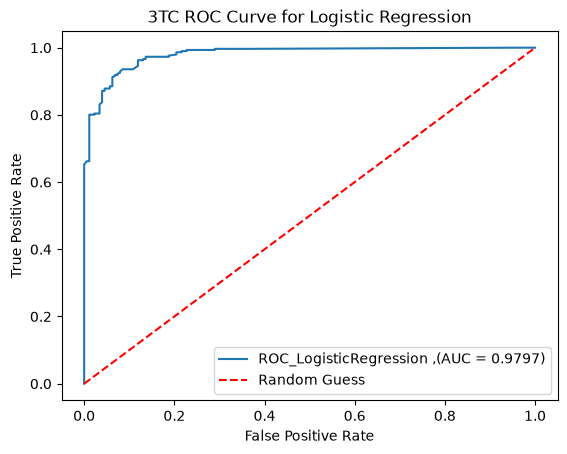

In [590]:
# Import required libraries
from sklearn.metrics import roc_curve, auc


# Generate y_scores from probability
y_3TC_scores = lr_3TC_model.predict_proba(X_3TC_test_array)[:, 1 ]

# Apply roc_curve to test and scores
fpr_3TC_lr, tpr_3TC_lr, thresholds  = roc_curve(y_3TC_test_array, y_3TC_scores)

#Plotting the curve

roc_auc_3TC_lr_score = auc(fpr_3TC_lr, tpr_3TC_lr)
plt.plot(fpr_3TC_lr, tpr_3TC_lr, label=f"ROC_LogisticRegression ,(AUC = {roc_auc_3TC_lr_score:.4f})")
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('3TC ROC Curve for Logistic Regression')
plt.legend()
plt.show()

##### Precision - Recall Curve

In [591]:
# Precision- Recall Curve
from sklearn.metrics import precision_recall_curve, auc

# Model prediction
y_3TC_pr_scores = lr_3TC_model.predict_proba(X_3TC_test_array)[:, 1] #extracts only the probability of the positive class (Resistancee)
precision_3TC, recall_3TC, thresholds = precision_recall_curve(y_3TC_test_array, y_3TC_pr_scores)
pr_auc_3TC_lr_score = auc(recall_3TC, precision_3TC)


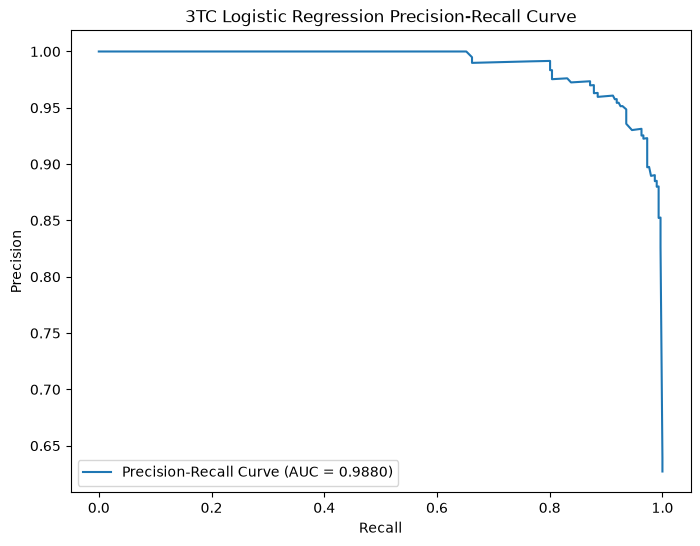

In [592]:
#Plotting PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall_3TC, precision_3TC, label=f'Precision-Recall Curve (AUC = {pr_auc_3TC_lr_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('3TC Logistic Regression Precision-Recall Curve')
plt.legend()
plt.show()

#### Confusion Matrix

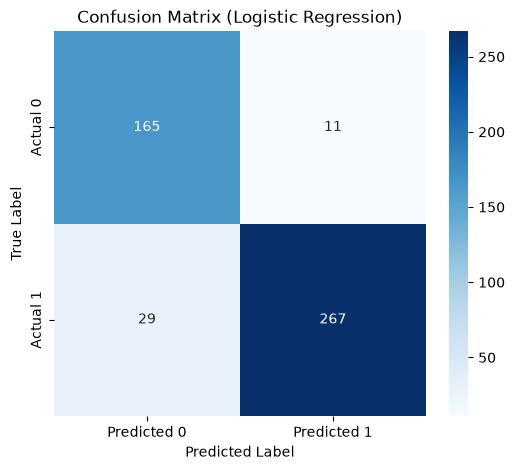

In [593]:
# Compute the confusion matrix values
cm_3TC_lr = confusion_matrix(y_3TC_test_array, y_3TC_pred_lr)

# 3. Plot confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_3TC_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix (Logistic Regression)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Model 2: Random Forest

In [594]:
from sklearn.ensemble import RandomForestClassifier

# Set parameters
rf_3TC_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

#Train model
rf_3TC_model.fit(X_3TC_train_array, y_3TC_train_array)

# Make Predictions
y_3TC_pred_rf = rf_3TC_model.predict(X_3TC_test_array)

##### Classification report

In [595]:
# Classification Report
from sklearn.metrics import classification_report

#Precision, Recall, and F1-Score for each class
print("--- Classification Report ---")
print(classification_report(y_3TC_test_array, y_3TC_pred_rf))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       176
           1       0.95      0.90      0.93       296

    accuracy                           0.91       472
   macro avg       0.90      0.91      0.91       472
weighted avg       0.91      0.91      0.91       472



#### Confusion Matrix

--- Confusion Matrix ---
[[163  13]
 [ 29 267]]


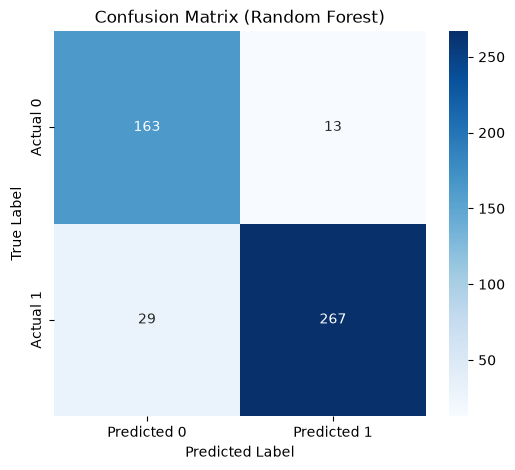

In [596]:
# Confusion Matrix 
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix values
cm_3TC_rf= confusion_matrix(y_3TC_test_array, y_3TC_pred_rf)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_3TC_test_array, y_3TC_pred_rf))

# Plotting confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_3TC_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix (Random Forest)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### Check for overfitting

In [597]:
# Look at cross validation hyper-parameter tuning
from sklearn.metrics import roc_auc_score

# Predict on the training data
y_3TC_train_pred = rf_3TC_model.predict(X_3TC_train_array)

print("--- TRAINING Classification Report ---")
print(classification_report(y_3TC_train_array, y_3TC_train_pred))

y_3TC_pred_proba = rf_3TC_model.predict_proba(X_3TC_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_3TC_train, y_3TC_pred_proba):.4f}")


--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       703
           1       0.99      0.95      0.97      1184

    accuracy                           0.96      1887
   macro avg       0.95      0.97      0.96      1887
weighted avg       0.96      0.96      0.96      1887

ROC-AUC Score: 0.9914


#### ROC_AUC SCore calculation

ROC-AUC Score: 0.9622


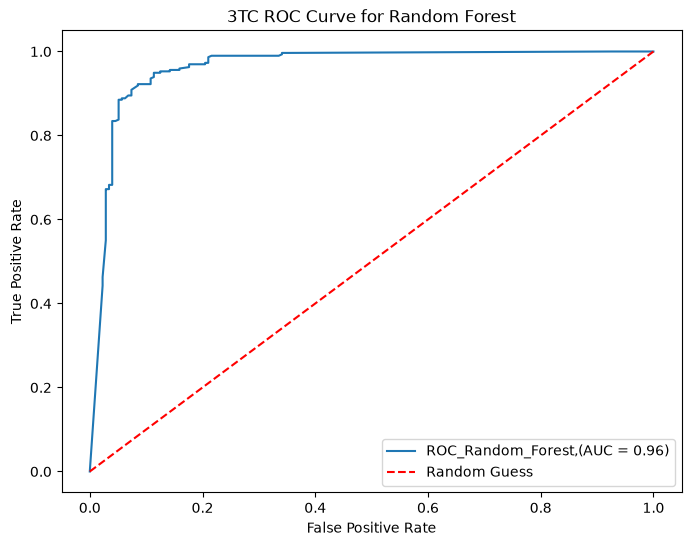

In [598]:
#Calculate ROC-AUC
from sklearn.metrics import roc_auc_score

y_3TC_pred_proba = rf_3TC_model.predict_proba(X_3TC_test_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_3TC_test_array, y_3TC_pred_proba):.4f}")

#Plotting an ROC curve
plt.figure(figsize =(8, 6))

y_3TC_rf_scores = rf_3TC_model.predict_proba(X_3TC_test_array)[:, 1]
fpr_3TC_rf, tpr_3TC_rf, _ = roc_curve (y_3TC_test_array, y_3TC_rf_scores)

roc_auc_3TC_rf_score = auc(fpr_3TC_rf, tpr_3TC_rf)

plt.plot(fpr_3TC_rf, tpr_3TC_rf, label =f"ROC_Random_Forest,(AUC = {roc_auc_3TC_rf_score:.2f})")
plt.plot([0,1],[0,1], "r--", label = "Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("3TC ROC Curve for Random Forest")
plt.legend()
plt.show()

#### Precision Recall curve

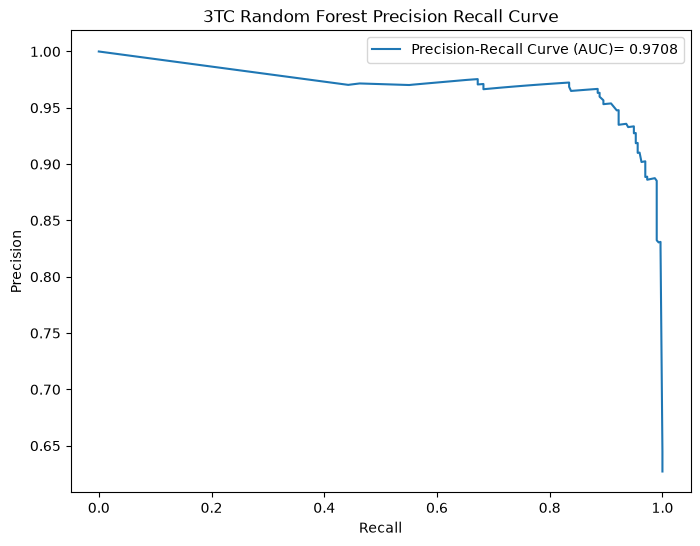

In [599]:
## Precision Recall curve to visualise how class imbalance impacted our model performance 
#Load libraries
from sklearn.metrics import precision_recall_curve, auc

# Model Precision
y_3TC_rf_scores = rf_3TC_model.predict_proba(X_3TC_test_array)[:, 1]
precision_3TC_rf, recall_3TC_rf, threshold = precision_recall_curve(y_3TC_test_array, y_3TC_rf_scores)
pr_auc_3TC_rf_score = auc(recall_3TC_rf, precision_3TC_rf)

#Plot Precision, recall curve
plt.figure(figsize = (8, 6))
plt.plot(recall_3TC_rf, precision_3TC_rf, label=f"Precision-Recall Curve (AUC)= {pr_auc_3TC_rf_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("3TC Random Forest Precision Recall Curve")
plt.legend()
plt.show()

### Model 3: Support Vector Machine

In [600]:
#Import model
from sklearn.svm import SVC

# Set parameters
svm_3TC_model = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)

# Train Model
svm_3TC_model.fit(X_3TC_train_array, y_3TC_train_array)

# Make prediction using model
y_3TC_pred_svm = svm_3TC_model.predict(X_3TC_test_array)

/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


#### Classification Report

In [601]:
#Generate Classification report
from sklearn.metrics import classification_report

print("--- SVM Test Classification Report ---")
print(classification_report(y_3TC_test_array, y_3TC_pred_svm))

--- SVM Test Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       176
           1       0.95      0.90      0.93       296

    accuracy                           0.91       472
   macro avg       0.90      0.91      0.91       472
weighted avg       0.91      0.91      0.91       472



#### Confusion Matrix

--- Confusion Matrix ---
[[163  13]
 [ 29 267]]


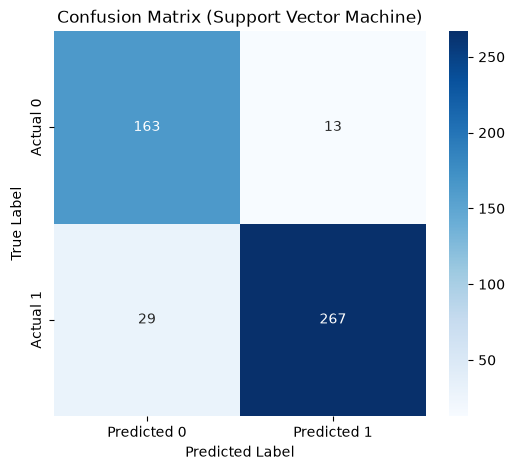

In [602]:
# Confusion kmatrix generation 
from sklearn.metrics import confusion_matrix

# Compute confusion matrix values
cm_3TC_svm = confusion_matrix(y_3TC_test_array, y_3TC_pred_svm)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_3TC_test, y_3TC_pred_svm))

# Plotting confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_3TC_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix (Support Vector Machine)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


#### Check for overfitting

In [603]:
# Look at cross validation hyper-parameter tuning
from sklearn.metrics import roc_auc_score

# Predict on the training data
y_3TC_train_pred = svm_3TC_model.predict(X_3TC_train_array)

print("--- TRAINING Classification Report ---")
print(classification_report(y_3TC_train_array, y_3TC_train_pred))

y_3TC_pred_proba = svm_model.predict_proba(X_3TC_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_3TC_train_array, y_3TC_pred_proba):.4f}")


--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       703
           1       0.97      0.91      0.94      1184

    accuracy                           0.93      1887
   macro avg       0.92      0.93      0.92      1887
weighted avg       0.93      0.93      0.93      1887

ROC-AUC Score: 0.9445


#### ROC- AUC score calculation and Plotting

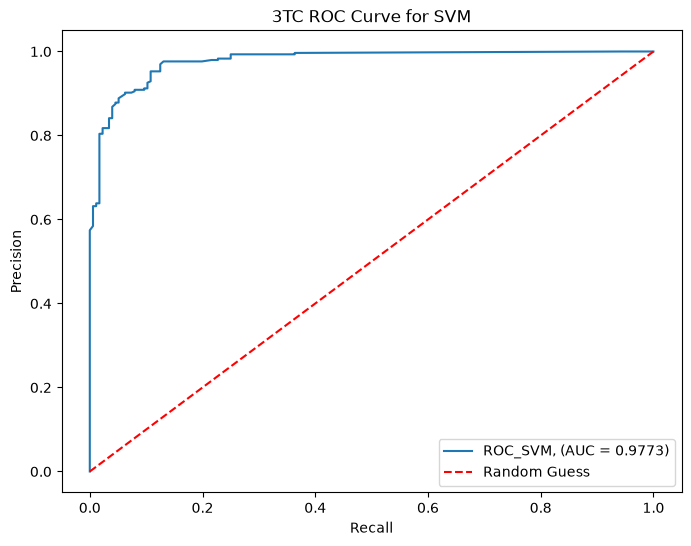

In [604]:
#Import required libraries
from sklearn.metrics import roc_curve, auc

# Generate scores
y_3TC_svm_scores = svm_3TC_model.predict_proba(X_3TC_test_array)[:, 1]

# Fit metrics to curve
fpr_3TC_svm, tpr_3TC_svm, _ = roc_curve(y_3TC_test_array, y_3TC_svm_scores)
roc_auc_3TC_svm_score = auc(fpr_3TC_svm, tpr_3TC_svm)

#Plot curve
plt.figure(figsize = (8,6))
plt.plot(fpr_3TC_svm, tpr_3TC_svm, label=f"ROC_SVM, (AUC = {roc_auc_3TC_svm_score:.4f})")
plt.plot([0,1],[0,1],"r--",label = "Random Guess")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("3TC ROC Curve for SVM")
plt.legend()
plt.show()

#### Precision Recall Curve 

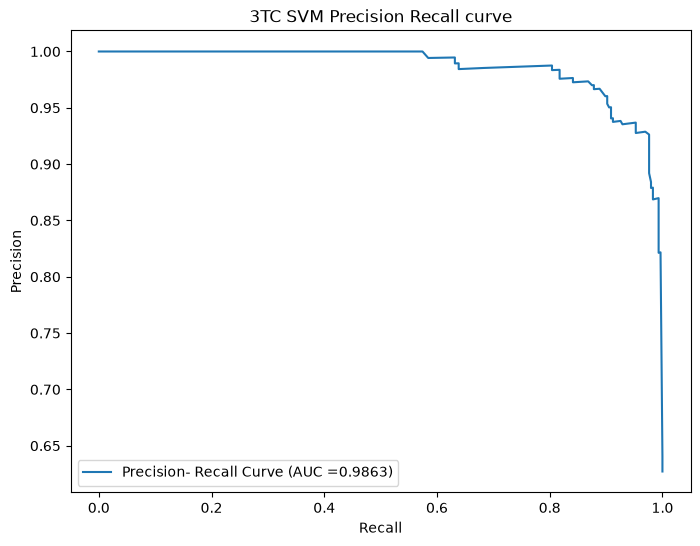

In [605]:
#Import required libraries
from sklearn.metrics import precision_recall_curve, auc

# Generate y_scores for plotting

y_3TC_svm_scores = svm_3TC_model.predict_proba(X_3TC_test_array)[:,1]
Precision_3TC_svm, Recall_3TC_svm, thresholds = precision_recall_curve(y_3TC_test_array,y_3TC_svm_scores)
pr_auc_3TC_svm_score = auc(Recall_3TC_svm, Precision_3TC_svm)

#Plot 
plt.figure(figsize = (8,6))
plt.plot(Recall_3TC_svm, Precision_3TC_svm, label= f"Precision- Recall Curve (AUC ={pr_auc_3TC_svm_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title ("3TC SVM Precision Recall curve")
plt.legend()
plt.show()

### Model 4: Extreme Gradient Boosting (XGBoost)

In [606]:
#Import required libraries
from xgboost import XGBClassifier 

# # scale_pos_weight handles class imbalance — ratio of susceptible to resistant
# scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_3TC_model = XGBClassifier(objective ="binary:logistic", random_state=42, eval_metric='logloss')
xgb_3TC_model.fit(X_3TC_train_array, y_3TC_train_array)
y_3TC_pred_xgb = xgb_3TC_model.predict(X_3TC_test_array)


#### Classification report

In [607]:
# Classification Report
from sklearn.metrics import classification_report

#Reporting
print("--- XgBoost Test Classification Report ---")
print(classification_report(y_3TC_test_array, y_3TC_pred_xgb))


--- XgBoost Test Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       176
           1       0.94      0.95      0.94       296

    accuracy                           0.93       472
   macro avg       0.93      0.92      0.93       472
weighted avg       0.93      0.93      0.93       472



#### Confusion Confusion Matrix 

--- Confusion Matrix ---
[[159  17]
 [ 16 280]]


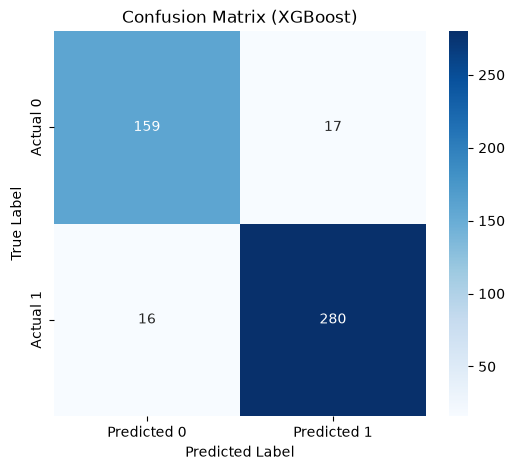

In [608]:
# Confusion kmatrix generation 
from sklearn.metrics import confusion_matrix

# Compute confusion matrix values
cm_3TC_xgb = confusion_matrix(y_3TC_test, y_3TC_pred_xgb)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_3TC_test_array, y_3TC_pred_xgb))

# Plotting confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_3TC_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix (XGBoost)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


#### Check overfitting

In [609]:
# Cross validate using Training set
# Predict on the training data
y_3TC_xgb_train_pred = xgb_3TC_model.predict(X_3TC_train_array)

print("--- TRAINING Classification Report ---")
print(classification_report(y_3TC_train_array, y_3TC_xgb_train_pred))

y_3TC_xgb_pred_proba = xgb_3TC_model.predict_proba(X_3TC_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_3TC_train_array, y_3TC_xgb_pred_proba):.4f}")


--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       703
           1       0.96      0.96      0.96      1184

    accuracy                           0.95      1887
   macro avg       0.94      0.95      0.95      1887
weighted avg       0.95      0.95      0.95      1887

ROC-AUC Score: 0.9868


#### ROC -AUC curves

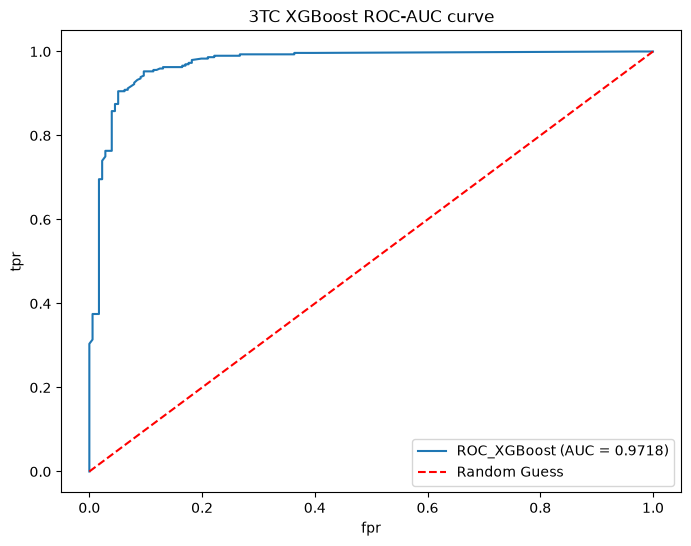

In [610]:
## Import required libraries
from sklearn.metrics import roc_curve, auc

## Generate y_xgb_scores 
y_3TC_xgb_scores = xgb_3TC_model.predict_proba(X_3TC_test_array)[:,1]

##Fill parameters
fpr_3TC_xgb, tpr_3TC_xgb, _ = roc_curve(y_3TC_test_array, y_3TC_xgb_scores)
roc_auc_3TC_xgb_score = auc(fpr_3TC_xgb, tpr_3TC_xgb)

## Plot roc_auc curves
plt.figure(figsize=(8,6))
plt.plot(fpr_3TC_xgb, tpr_3TC_xgb, label=f"ROC_XGBoost (AUC = {roc_auc_3TC_xgb_score:.4f})")
plt.plot([0,1],[0,1],"r--", label="Random Guess")
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("3TC XGBoost ROC-AUC curve")
plt.legend()
plt.show()


#### Precision Recall curve

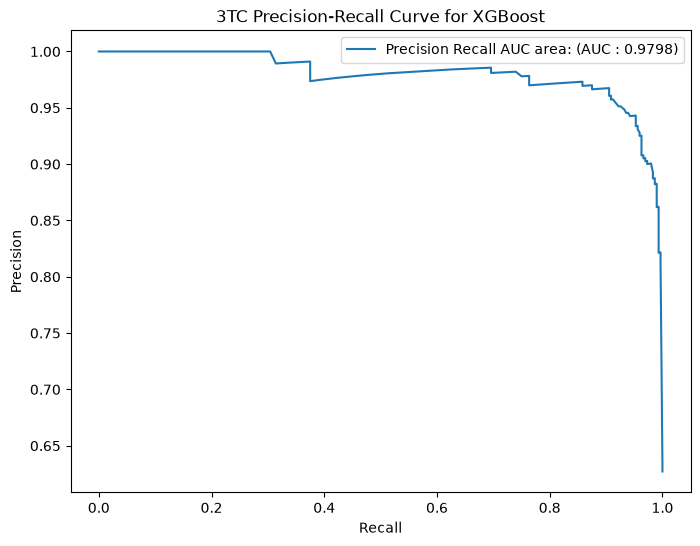

In [611]:
#Import required libraries
from sklearn.metrics import precision_recall_curve, auc

#Generate scores
y_3TC_xgb_scores = xgb_3TC_model.predict_proba(X_3TC_test_array)[:,1]

#Add parameters
precision_3TC_xgb, recall_3TC_xgb, threshold = precision_recall_curve(y_3TC_test_array, y_3TC_xgb_scores)
auc_3TC_xgb_score = auc(recall_3TC_xgb, precision_3TC_xgb)

#Plot Precision Recall Curve
plt.figure(figsize=(8,6))
plt.plot(recall_3TC_xgb, precision_3TC_xgb, label = f"Precision Recall AUC area: (AUC : {auc_3TC_xgb_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("3TC Precision-Recall Curve for XGBoost")
plt.legend()
plt.show()

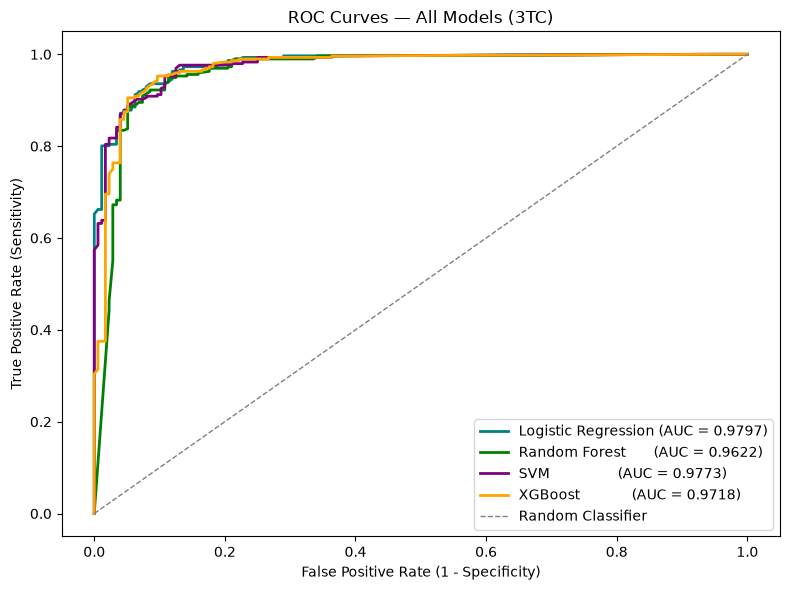

In [612]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_3TC_lr,  tpr_3TC_lr,  color='teal',   lw=2, label=f'Logistic Regression (AUC = {roc_auc_3TC_lr_score:.4f})')
plt.plot(fpr_3TC_rf,  tpr_3TC_rf,  color='green',  lw=2, label=f'Random Forest       (AUC = {roc_auc_3TC_rf_score:.4f})')
plt.plot(fpr_3TC_svm, tpr_3TC_svm, color='purple', lw=2, label=f'SVM                 (AUC = {roc_auc_3TC_svm_score:.4f})')
plt.plot(fpr_3TC_xgb, tpr_3TC_xgb, color='orange', lw=2, label=f'XGBoost             (AUC = {roc_auc_3TC_xgb_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves — All Models (3TC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [613]:
from sklearn.metrics import matthews_corrcoef

#Get the MCC for each model
mcc_lr_3TC = matthews_corrcoef(y_3TC_test_array, y_3TC_pred_lr)
mcc_rf_3TC = matthews_corrcoef(y_3TC_test_array, y_3TC_pred_rf)
mcc_svm_3TC = matthews_corrcoef(y_3TC_test_array, y_3TC_pred_svm)
mcc_xgb_3TC = matthews_corrcoef(y_3TC_test_array, y_3TC_pred_xgb)

#Rank the models by MCC
mcc_scores = {"LR": (mcc_lr_3TC, lr_3TC_model),
              "RF": (mcc_rf_3TC, rf_3TC_model),
              "SVM": (mcc_svm_3TC, svm_3TC_model),
              "XGB": (mcc_xgb_3TC, xgb_3TC_model),
              }

mcc_ranked = sorted(mcc_scores.items(), key=lambda x:x[1][0], reverse = True)

print("Model Ranking by MCC (3TC) ")
print(f"\n{'Rank':<6} {'Model':<22} {'MCC':>8}")
for rank, (name, (mcc, _)) in enumerate(mcc_ranked, start=1):
    print(f"{rank:<6} {name:<22} {mcc:>8.4f}")

#Save the best model into a pkl file
best_name, (best_mcc, best_model) = mcc_ranked[0]

joblib.dump(best_model, '/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_3TC.pkl')

print(f"\nBest model : {best_name}")

Model Ranking by MCC (3TC) 

Rank   Model                       MCC
1      XGB                      0.8503
2      LR                       0.8251
3      RF                       0.8152
4      SVM                      0.8152

Best model : XGB


## TDF Training

In [614]:
#Train model for 3TC prediction
# Data ------> ~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_TDF.csv
import pandas as pd

# import data
#df_TDF = pd.read_csv("~/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/Day4/drug_dfs/df_TDF.csv") #Row numbers excluded
df_TDF.head(n = 30)

,IsolateID,NRTIDRMs,TDF_FoldChange,Mutation_List,resistance,MutationListFiltered
0,10626,"D67N, T69D, K70R, T215F, K219Q",0.9,"[D67N, T69D, K70R, T215F, K219Q]",0,"[D67N, T69D, K70R, T215F, K219Q]"
1,15983,"M41L, D67N, M184V, L210W, T215Y",0.9,"[M41L, D67N, M184V, L210W, T215Y]",0,"[M41L, D67N, M184V, L210W, T215Y]"
2,11732,"M41L, L74V, L210W, T215Y",1.4,"[M41L, L74V, L210W, T215Y]",1,"[M41L, L74V, L210W, T215Y]"
3,11961,"D67N, K70R, M184V, T215V, K219Q",0.9,"[D67N, K70R, M184V, T215V, K219Q]",0,"[D67N, K70R, M184V, K219Q]"
4,11193,"E40F, M41L, D67N, L210W, T215Y, K219N",4.6,"[E40F, M41L, D67N, L210W, T215Y, K219N]",1,"[M41L, D67N, L210W, T215Y, K219N]"
5,24202,"M41L, T69S_SS, L210W, T215Y",28.0,"[M41L, T69S_SS, L210W, T215Y]",1,"[M41L, L210W, T215Y]"
6,13897,"M41L, A62V, V75T, M184V, T215Y",1.1,"[M41L, A62V, V75T, M184V, T215Y]",0,"[M41L, A62V, V75T, M184V, T215Y]"
7,4364,"S68G, F116Y, Q151M",0.9,"[S68G, F116Y, Q151M]",0,"[S68G, F116Y, Q151M]"
8,10967,"A62V, L74V, V75T",0.4,"[A62V, L74V, V75T]",0,"[A62V, L74V, V75T]"
9,16903,"M41L, D67N, T215Y",2.7,"[M41L, D67N, T215Y]",1,"[M41L, D67N, T215Y]"


In [615]:
### Create X data frame
X_tdf = df_TDF[["IsolateID","MutationListFiltered"]]
X_tdf.head(n = 5)

,IsolateID,MutationListFiltered
0,10626,"[D67N, T69D, K70R, T215F, K219Q]"
1,15983,"[M41L, D67N, M184V, L210W, T215Y]"
2,11732,"[M41L, L74V, L210W, T215Y]"
3,11961,"[D67N, K70R, M184V, K219Q]"
4,11193,"[M41L, D67N, L210W, T215Y, K219N]"


In [616]:
### Create y data frame
y_tdf = df_TDF["resistance"]
y_tdf.head(n = 10)

### Assess class imbalance is needed based on target y == df_3TC["resistance"](Resistance: Susceptible = 1.7:1.0) - mild class imbalance
y_tdf.value_counts() 

resistance
0    1305
1     707
Name: count, dtype: int64

In [617]:
### Split dataset
from sklearn.model_selection import train_test_split

import pandas as pd


X_tdf_train, X_tdf_test, y_tdf_train, y_tdf_test = train_test_split( X_tdf, y_tdf , test_size=0.2, random_state=42, stratify = y)
print(y_tdf_train.value_counts()) 
print(y_tdf_test.value_counts())


## Inspecting Dimensionality of Split Dataset
#Inspect X_train
print(f"X_tdf_train: {X_tdf_train}")
print(f"y_tdf_train: {y_tdf_train}")

print(f"X_tdf_test: {X_tdf_test}")
print(f"y_tdf_test: {y_tdf_test}")

# # Inspect X_test
X_tdf_test.shape

# # #Inspect y_train
y_tdf_train.shape

# # # #Inspect y_test
y_tdf_test.shape

resistance
0    1044
1     565
Name: count, dtype: int64
resistance
0    261
1    142
Name: count, dtype: int64
X_tdf_train:       IsolateID                               MutationListFiltered
1713     592386            [M41L, E44D, S68G, M184V, L210W, T215Y]
76        48753                                             [K70R]
1745     591826                                [D67N, T69D, K219N]
1209      68911                                                 []
284       43066  [M41L, E44D, D67N, L74V, M184V, L210W, T215Y, ...
...         ...                                                ...
389       92277  [M41L, E44A, D67N, T69D, V75M, M184V, L210W, T...
1968     591422                                                 []
418       92289                               [M41L, L210W, T215Y]
1812     592016                                                 []
1402     237847                                                 []

[1609 rows x 2 columns]
y_tdf_train: 1713    1
76      0
1745    0
120

(403,)

In [618]:
### Generate Mutation matrix (Feature Matrix) for X_train
#Load required libraries
from sklearn.preprocessing import MultiLabelBinarizer

#Mutation matrix:
## X_Train matrix 
mlb_features = MultiLabelBinarizer(classes = relevant_mutations)
X_tdf_train_array = mlb_features.fit_transform(X_tdf_train["MutationListFiltered"])
X_tdf_train_array.shape
X_tdf_train_array

mlb_features.classes_

# Generate Mutation matrix (Feature Matrix) for X_test
# X_Test matrix
X_tdf_test_array = mlb_features.transform(X_tdf_test["MutationListFiltered"])
X_tdf_test_array.shape
X_tdf_test_array

#y_matrix
y_tdf_train_array = y_tdf_train.values
y_tdf_test_array = y_tdf_test.values

# # Extract target
# # #y_test and y_train do not need transformation
print(y_tdf_train_array)
y_tdf_test_array



y_tdf_test_array.shape


y_tdf_train.shape
# X_train_array.shape

[1 0 0 ... 1 0 0]


(1609,)

### Model 1: Logistic Regression 

In [619]:
from sklearn.linear_model import LogisticRegression

lr_tdf_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_tdf_model.fit(X_tdf_train_array, y_tdf_train_array)
y_tdf_pred_lr = lr_tdf_model.predict(X_tdf_test_array)
y_tdf_pred_lr

array([0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,

In [620]:
#LR Performance Metrics Evaluation (Classification Report, Confusion Matrix, Precision- Recall curves)
#Import model evaluation tools
import matplotlib.pyplot as plt
import seaborn as sns

##### Classification report

In [621]:
## Classification Report
from sklearn.metrics import classification_report, confusion_matrix

print("---Logistic Regression Classification Report:")
print(classification_report(y_tdf_test_array, y_tdf_pred_lr))


---Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       261
           1       0.72      0.89      0.80       142

    accuracy                           0.84       403
   macro avg       0.83      0.85      0.83       403
weighted avg       0.86      0.84      0.84       403



#### Check for overfitting

In [622]:
# Look at cross validation hyper-parameter tuning
from sklearn.metrics import roc_auc_score

# Predict on the training data
y_tdf_train_pred = lr_tdf_model.predict(X_tdf_train_array)

print("--- TRAINING Classification Report ---")
print(classification_report(y_tdf_train_array, y_tdf_train_pred))

y_tdf_pred_proba = lr_tdf_model.predict_proba(X_tdf_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_tdf_train, y_tdf_pred_proba):.4f}")

--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.80      0.84      1044
           1       0.69      0.83      0.75       565

    accuracy                           0.81      1609
   macro avg       0.79      0.81      0.80      1609
weighted avg       0.82      0.81      0.81      1609

ROC-AUC Score: 0.9010


#### Plotting ROC-AUC curves

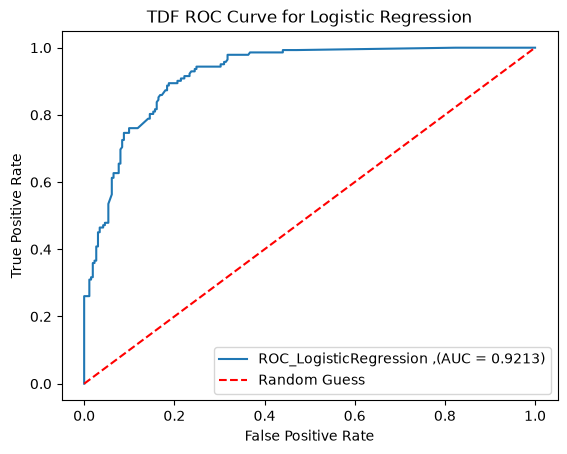

In [623]:
# Import required libraries
from sklearn.metrics import roc_curve, auc


# Generate y_scores from probability
y_tdf_lr_scores = lr_tdf_model.predict_proba(X_tdf_test_array)[:, 1 ]

# Apply roc_curve to test and scores
fpr_tdf_lr, tpr_tdf_lr, thresholds  = roc_curve(y_tdf_test_array, y_tdf_lr_scores)

#Plotting the curve

roc_tdf_lr_auc_score = auc(fpr_tdf_lr, tpr_tdf_lr)
plt.plot(fpr_tdf_lr, tpr_tdf_lr, label=f"ROC_LogisticRegression ,(AUC = {roc_tdf_lr_auc_score:.4f})")
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('TDF ROC Curve for Logistic Regression')
plt.legend()
plt.show()

#### Precision Recall Curves 

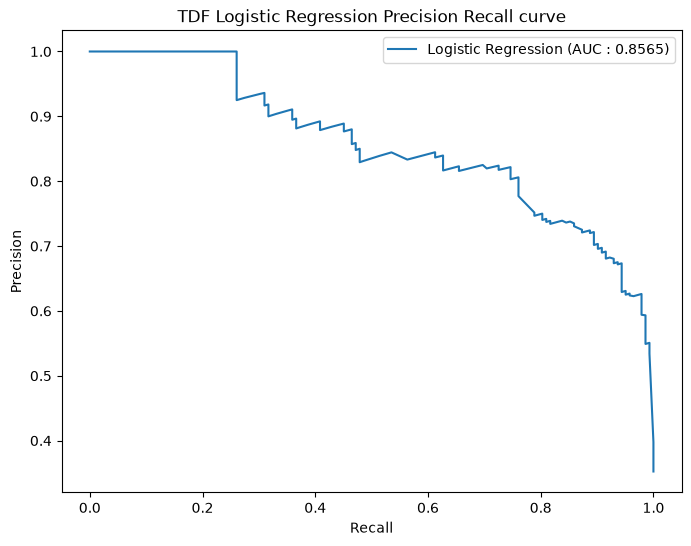

In [624]:
#Import required libraries
from sklearn.metrics import precision_recall_curve, auc

# Generate y_lr_scores
y_tdf_lr_pr_scores = lr_tdf_model.predict_proba(X_tdf_test_array)[:,1]

# Extract metrics
precision_tdf_lr, recall_tdf_lr, thresholds = precision_recall_curve(y_tdf_test_array, y_tdf_lr_scores)

# auc scores
pr_auc_tdf_lr_score = auc(recall_tdf_lr, precision_tdf_lr)

# Plotting
plt.figure(figsize =(8,6))
plt.plot(recall_tdf_lr, precision_tdf_lr, label=f"Logistic Regression (AUC : {pr_auc_tdf_lr_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("TDF Logistic Regression Precision Recall curve")
plt.legend()
plt.show()

### Model 2: Random Forest 

In [625]:
# Running the Random Forest model

#Import required libraries
from sklearn.ensemble import RandomForestClassifier

rf_tdf_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight="balanced" )

# Train the model
rf_tdf_model.fit(X_tdf_train_array, y_tdf_train_array)

# Make predictions
y_tdf_pred_rf = rf_tdf_model.predict(X_tdf_test_array)

#### Classification Report

In [626]:
#Classification Report


print("---- TDF Random Forest Classification Report:")
print(classification_report(y_tdf_test_array, y_tdf_pred_rf))

y_tdf_rf_pred_proba = rf_tdf_model.predict_proba(X_tdf_test_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_tdf_test_array, y_tdf_rf_pred_proba):.4f}")

---- TDF Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       261
           1       0.70      0.80      0.74       142

    accuracy                           0.81       403
   macro avg       0.79      0.80      0.79       403
weighted avg       0.82      0.81      0.81       403

ROC-AUC Score: 0.8782


#### Confusion Matrix

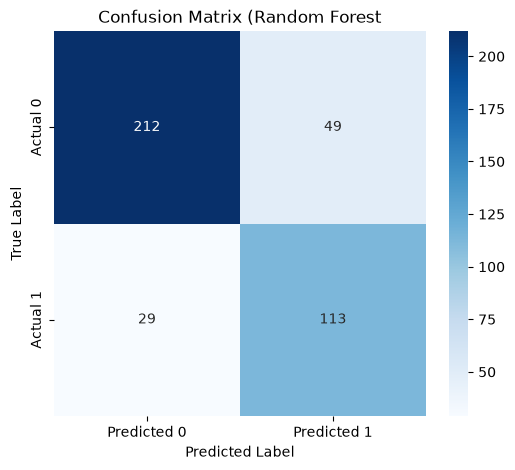

In [627]:
#Import required packages
from sklearn.metrics import confusion_matrix

cm_tdf_rf = confusion_matrix(y_tdf_test_array, y_tdf_pred_rf)

# Compute the confusion matrix values
cm_tdf_rf = confusion_matrix(y_tdf_test_array, y_tdf_pred_rf)

# 3. Plot confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tdf_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix (Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### Check For Overfitting

In [628]:
# Look at cross validation hyper-parameter tuning
from sklearn.metrics import roc_auc_score

# Predict on the training data
y_tdf_train_pred = rf_tdf_model.predict(X_tdf_train_array)
y_tdf_train_pred_proba = rf_model.predict_proba(X_tdf_train_array)[:, 1]

print("--- TRAINING Classification Report ---")
print(classification_report(y_tdf_train_array, y_tdf_train_pred))

y_tdf_pred_proba = lr_tdf_model.predict_proba(X_tdf_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_tdf_train_array, y_tdf_pred_proba):.4f}")

--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1044
           1       0.86      0.93      0.89       565

    accuracy                           0.92      1609
   macro avg       0.91      0.92      0.92      1609
weighted avg       0.92      0.92      0.92      1609

ROC-AUC Score: 0.9010


##### Plotting ROC- AUC curves

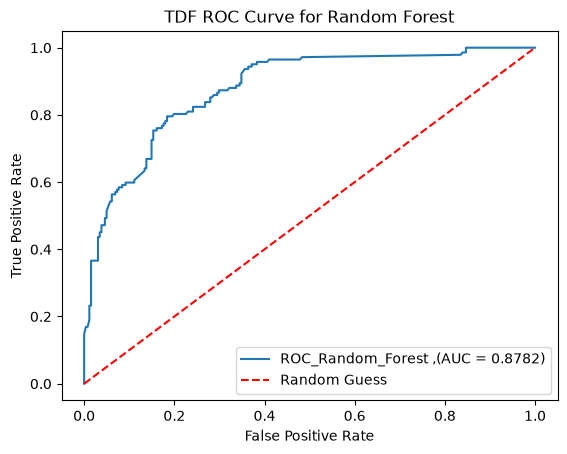

In [629]:
# Import tools
from sklearn.metrics import roc_curve

#Generate y_rf_scores
y_tdf_rf_scores = rf_tdf_model.predict_proba(X_tdf_test_array)[:,1]

#Extract parameters
fpr_tdf_rf, tpr_tdf_rf, thresholds = roc_curve(y_tdf_test, y_tdf_rf_scores)

# Plotting ROC_AUC curves
roc_tdf_rf_auc_score = auc(fpr_tdf_rf, tpr_tdf_rf)
plt.plot(fpr_tdf_rf, tpr_tdf_rf, label=f"ROC_Random_Forest ,(AUC = {roc_tdf_rf_auc_score:.4f})")
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('TDF ROC Curve for Random Forest')
plt.legend()
plt.show()


#### Precision- Recall curves

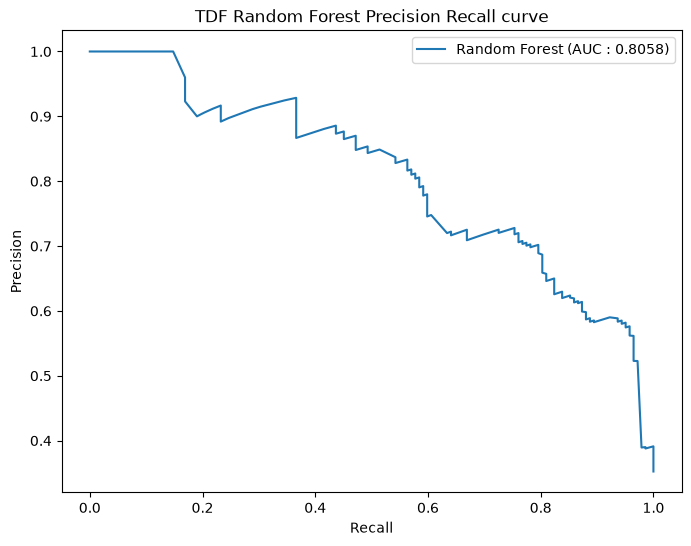

In [630]:
#Import required libraries
from sklearn.metrics import precision_recall_curve, auc

# Generate y_rf_scores
y_tdf_rf_scores = rf_tdf_model.predict_proba(X_tdf_test_array)[:,1]

# Extract metrics
precision_tdf_rf, recall_tdf_rf, thresholds = precision_recall_curve(y_tdf_test_array, y_tdf_rf_scores)

# auc scores
pr_tdf_rf_auc_score = auc(recall_tdf_rf, precision_tdf_rf)

# Plotting
plt.figure(figsize =(8,6))
plt.plot(recall_tdf_rf, precision_tdf_rf, label=f"Random Forest (AUC : {pr_tdf_rf_auc_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("TDF Random Forest Precision Recall curve")
plt.legend()
plt.show()

#### Model 3: Support Vector Machine (SVM)

In [631]:
#Import require libraries
from sklearn.svm import SVC

# Set parameters
svm_tdf_model = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)

# Train Model
svm_tdf_model.fit(X_tdf_train_array, y_tdf_train_array)

# Make prediction using model
y_tdf_pred_svm = svm_tdf_model.predict(X_tdf_test_array)

/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


#### Classification Report Generation

In [632]:
#Generate Classification report
from sklearn.metrics import classification_report

print("--- SVM Test Classification Report ---")
print(classification_report(y_tdf_test_array, y_tdf_pred_svm))



--- SVM Test Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.79      0.85       261
           1       0.69      0.86      0.77       142

    accuracy                           0.82       403
   macro avg       0.80      0.83      0.81       403
weighted avg       0.83      0.82      0.82       403



#### Confusion Matrix

--- Confusion Matrix ---
[[207  54]
 [ 20 122]]


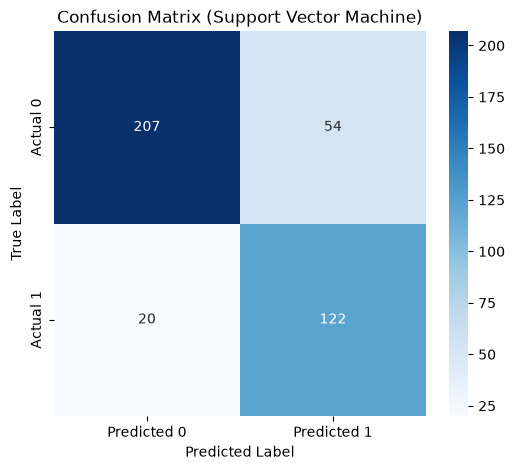

In [633]:
# Confusion kmatrix generation 
from sklearn.metrics import confusion_matrix

# Compute confusion matrix values
cm_tdf_svm = confusion_matrix(y_tdf_test_array, y_tdf_pred_svm)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_tdf_test_array, y_tdf_pred_svm))

# Plotting confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tdf_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix (Support Vector Machine)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### Check for Overfitting

In [634]:
# Look at cross validation hyper-parameter tuning
from sklearn.metrics import roc_auc_score

# Predict on the training data
y_tdf_train_pred = svm_tdf_model.predict(X_tdf_train_array)
y_tdf_train_pred_proba = svm_tdf_model.predict_proba(X_tdf_train_array)[:, 1]

print("--- TRAINING Classification Report ---")
print(classification_report(y_tdf_train_array, y_tdf_train_pred))

y_tdf_pred_proba = svm_tdf_model.predict_proba(X_tdf_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_tdf_train_array, y_tdf_pred_proba):.4f}")

--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1044
           1       0.70      0.85      0.77       565

    accuracy                           0.82      1609
   macro avg       0.80      0.82      0.81      1609
weighted avg       0.83      0.82      0.82      1609

ROC-AUC Score: 0.8985


#### ROC-AUC Calculation and Plotting

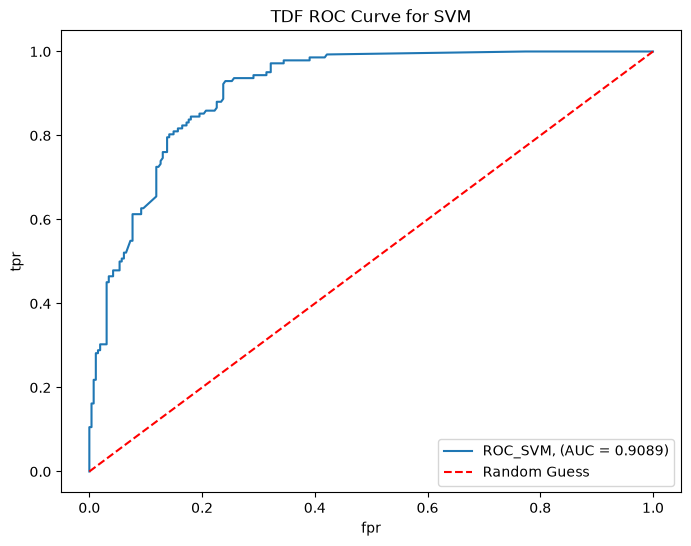

In [635]:
#Import required libraries
from sklearn.metrics import roc_curve, auc

# Generate scores
y_tdf_svm_scores = svm_tdf_model.predict_proba(X_tdf_test_array)[:, 1]

# Fit metrics to curve
fpr_tdf_svm, tpr_tdf_svm, _ = roc_curve(y_tdf_test, y_tdf_svm_scores)
roc_tdf_svm_auc_score = auc(fpr_tdf_svm, tpr_tdf_svm)

#Plot curve
plt.figure(figsize = (8,6))
plt.plot(fpr_tdf_svm, tpr_tdf_svm, label=f"ROC_SVM, (AUC = {roc_tdf_svm_auc_score :.4f})")
plt.plot([0,1],[0,1],"r--",label = "Random Guess")
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("TDF ROC Curve for SVM")
plt.legend()
plt.show()

#### Precision-Recall curve for SVM

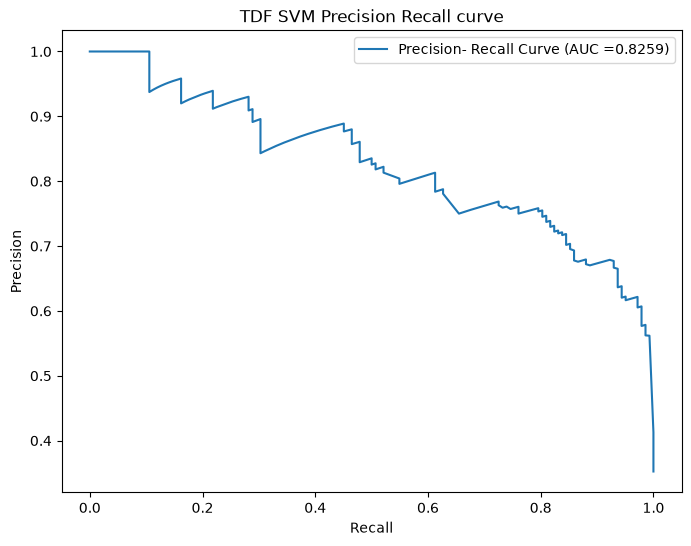

In [636]:
#Import required libraries
from sklearn.metrics import precision_recall_curve, auc

# Generate y_scores for plotting

y_tdf_svm_scores = svm_tdf_model.predict_proba(X_tdf_test_array)[:,1]
precision_tdf_svm, recall_tdf_svm, thresholds = precision_recall_curve(y_tdf_test_array,y_tdf_svm_scores)
pr_tdf_auc_score = auc(recall_tdf_svm, precision_tdf_svm)

#Plot 
plt.figure(figsize = (8,6))
plt.plot(recall_tdf_svm, precision_tdf_svm, label= f"Precision- Recall Curve (AUC ={pr_tdf_auc_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title ("TDF SVM Precision Recall curve")
plt.legend()
plt.show()

### Model4: Extreme Gradient Boost (XGBoost)

In [637]:
#Import required libraries
from xgboost import XGBClassifier 

# # scale_pos_weight handles class imbalance (positive class is minority class)
scale = (y_tdf_train_array == 0).sum() / (y_tdf_train_array == 1).sum()

xgb_tdf_model = XGBClassifier(objective ="binary:logistic", random_state=42, eval_metric='logloss')
xgb_tdf_model.fit(X_tdf_train_array, y_tdf_train_array)
y_tdf_pred_xgb = xgb_tdf_model.predict(X_tdf_test_array)

#### Classification Report

In [638]:
# Classification Report
from sklearn.metrics import classification_report

#Reporting
print("--- XgBoost Test Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

y_tdf_pred_proba = xgb_tdf_model.predict_proba(X_tdf_test_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_tdf_test, y_tdf_pred_proba):.4f}")

--- XgBoost Test Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       261
           1       0.73      0.76      0.75       142

    accuracy                           0.82       403
   macro avg       0.80      0.81      0.80       403
weighted avg       0.82      0.82      0.82       403

ROC-AUC Score: 0.8999


#### Confusion Matrix

--- Confusion Matrix ---
[[222  39]
 [ 34 108]]


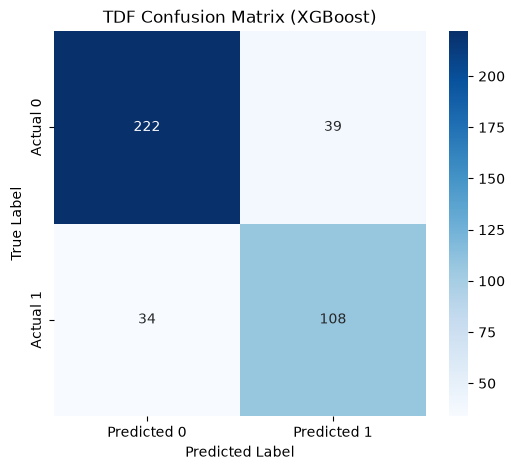

In [639]:
# Confusion kmatrix generation 
from sklearn.metrics import confusion_matrix

# Compute confusion matrix values
cm_tdf_xgb = confusion_matrix(y_tdf_test_array, y_tdf_pred_xgb)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_tdf_test_array, y_tdf_pred_xgb))

# Plotting confusion matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tdf_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('TDF Confusion Matrix (XGBoost)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### Check for Overfitting

In [640]:
# Cross validate using Training set
# Predict on the training data
y_tdf_train_pred = xgb_tdf_model.predict(X_tdf_train_array)
y_train_pred_proba = xgb_tdf_model.predict_proba(X_tdf_train_array)[:, 1]

print("--- TRAINING Classification Report ---")
print(classification_report(y_tdf_train, y_tdf_train_pred))

y_tdf_pred_proba = xgb_tdf_model.predict_proba(X_tdf_train_array)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_tdf_train, y_tdf_pred_proba):.4f}")

--- TRAINING Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1044
           1       0.87      0.86      0.86       565

    accuracy                           0.90      1609
   macro avg       0.90      0.89      0.89      1609
weighted avg       0.90      0.90      0.90      1609

ROC-AUC Score: 0.9607


#### ROC-AUC curves calculations and Plotting

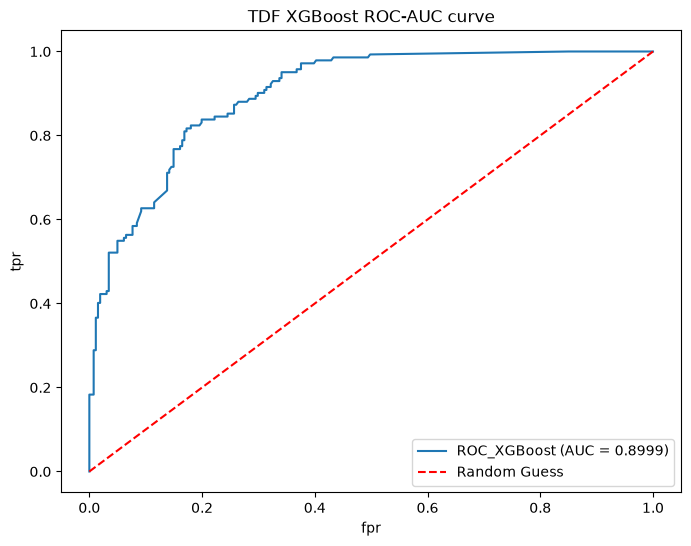

In [641]:
## Import required libraries
from sklearn.metrics import roc_curve, auc

## Generate y_xgb_scores 
y_tdf_xgb_scores = xgb_tdf_model.predict_proba(X_tdf_test_array)[:,1]

##Fill parameters
fpr_tdf_xgb, tpr_tdf_xgb, _ = roc_curve(y_tdf_test_array, y_tdf_xgb_scores)
roc_tdf_xgb_auc_score = auc(fpr_tdf_xgb, tpr_tdf_xgb)

## Plot roc_auc curves
plt.figure(figsize=(8,6))
plt.plot(fpr_tdf_xgb, tpr_tdf_xgb, label=f"ROC_XGBoost (AUC = {roc_tdf_xgb_auc_score:.4f})")
plt.plot([0,1],[0,1],"r--", label="Random Guess")
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("TDF XGBoost ROC-AUC curve")
plt.legend()
plt.show()

#### Precision- Recall Curve

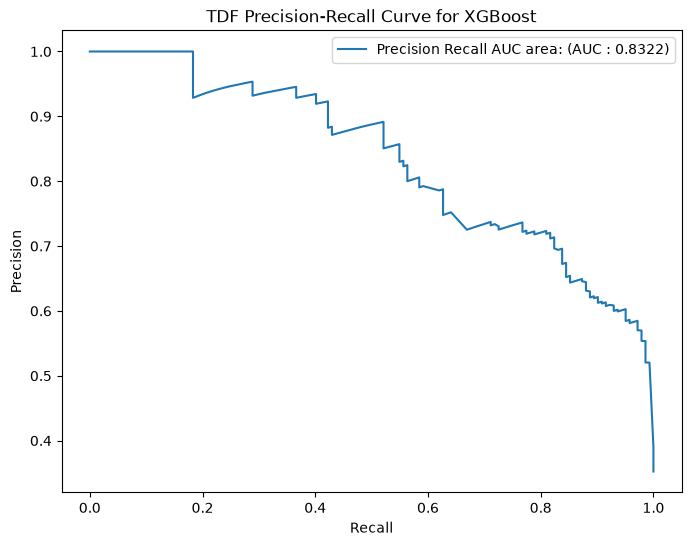

In [642]:
#Import required libraries
from sklearn.metrics import precision_recall_curve, auc

#Generate scores
y_tdf_xgb_scores = xgb_tdf_model.predict_proba(X_tdf_test_array)[:,1]

#Add parameters
precision_tdf_xgb, recall_tdf_xgb, threshold = precision_recall_curve(y_tdf_test_array, y_tdf_xgb_scores)
pr_tdf_xgb_auc_score = auc(recall_tdf_xgb, precision_tdf_xgb)

#Plot Precision Recall Curve
plt.figure(figsize=(8,6))
plt.plot(recall_tdf_xgb, precision_tdf_xgb, label = f"Precision Recall AUC area: (AUC : {pr_tdf_xgb_auc_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("TDF Precision-Recall Curve for XGBoost")
plt.legend()
plt.show()

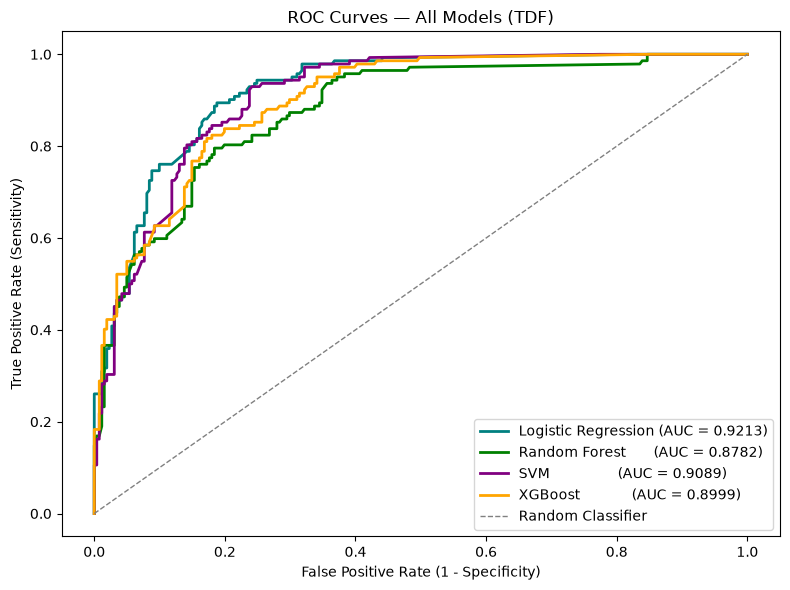

In [643]:
#Combined TDF ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_tdf_lr,  tpr_tdf_lr,  color='teal',   lw=2, label=f'Logistic Regression (AUC = {roc_tdf_lr_auc_score:.4f})')
plt.plot(fpr_tdf_rf,  tpr_tdf_rf,  color='green',  lw=2, label=f'Random Forest       (AUC = {roc_tdf_rf_auc_score:.4f})')
plt.plot(fpr_tdf_svm, tpr_tdf_svm, color='purple', lw=2, label=f'SVM                 (AUC = {roc_tdf_svm_auc_score:.4f})')
plt.plot(fpr_tdf_xgb, tpr_tdf_xgb, color='orange', lw=2, label=f'XGBoost             (AUC = {roc_tdf_xgb_auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves — All Models (TDF)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### AZT Model Training

In [644]:
#Split the AZT dataset - 80/20
train_df_AZT, test_df_AZT = train_test_split(df_AZT, test_size=0.2, random_state=42,stratify = df_AZT['resistance'])
train_df_AZT.shape

(1904, 6)

In [645]:
# Generate the mutation matrix using MLB
from sklearn.preprocessing import MultiLabelBinarizer

# Fit MLB on features training df and use transform on features test df
mlb = MultiLabelBinarizer(classes=relevant_mutations)
X_train_AZT = mlb.fit_transform(train_df_AZT['MutationListFiltered'])
X_test_AZT  = mlb.transform(test_df_AZT['MutationListFiltered'])
X_train_AZT.shape

(1904, 42)

In [646]:
# Extract Target
y_train_AZT = train_df_AZT['resistance'].values #
y_test_AZT = test_df_AZT['resistance'].values


**Logistic regression - AZT**

In [647]:
#Train the model and predict
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_AZT, y_train_AZT)
y_pred_lr = lr_model.predict(X_test_AZT)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       230
           1       0.93      0.91      0.92       247

    accuracy                           0.92       477
   macro avg       0.92      0.92      0.92       477
weighted avg       0.92      0.92      0.92       477



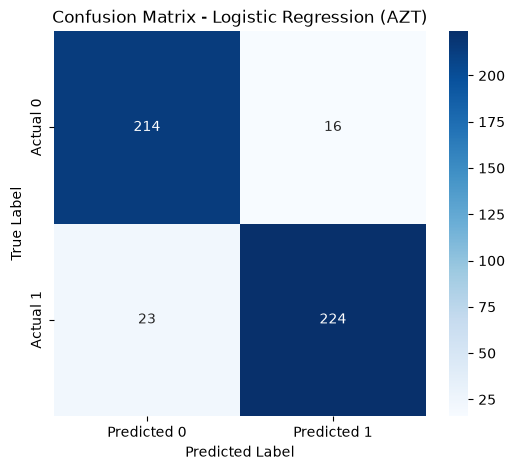

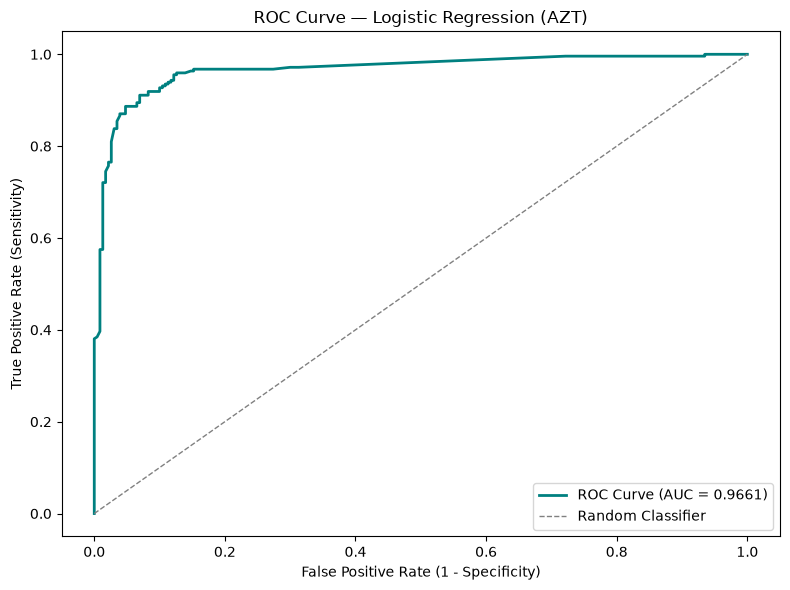

In [648]:
#LR Performance Metrics
# 1. Print the text-based classification report
print("Classification Report:")
print(classification_report(y_test_AZT, y_pred_lr))

# 2. Compute the confusion matrix values
cm_lr = confusion_matrix(y_test_AZT, y_pred_lr)

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix - Logistic Regression (AZT)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Get and plot the ROC curve metrics
y_pred_proba_lr = lr_model.predict_proba(X_test_AZT)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_AZT, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test_AZT, y_pred_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='teal', lw=2, label=f'ROC Curve (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Logistic Regression (AZT)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Random Forest**

In [649]:
#Train and test the model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_AZT, y_train_AZT)
y_pred_rf = rf_model.predict(X_test_AZT)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       230
           1       0.95      0.92      0.93       247

    accuracy                           0.93       477
   macro avg       0.93      0.93      0.93       477
weighted avg       0.93      0.93      0.93       477

--- Confusion Matrix ---
[[217  13]
 [ 19 228]]


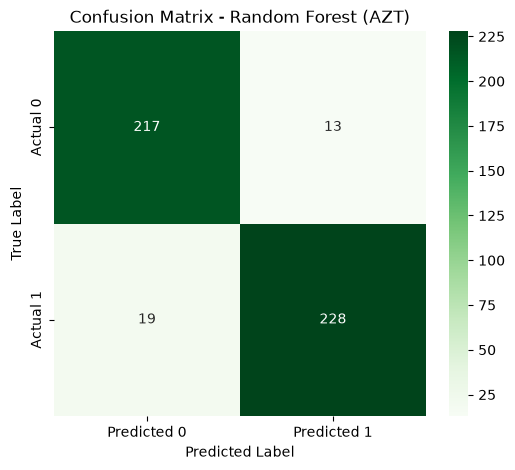

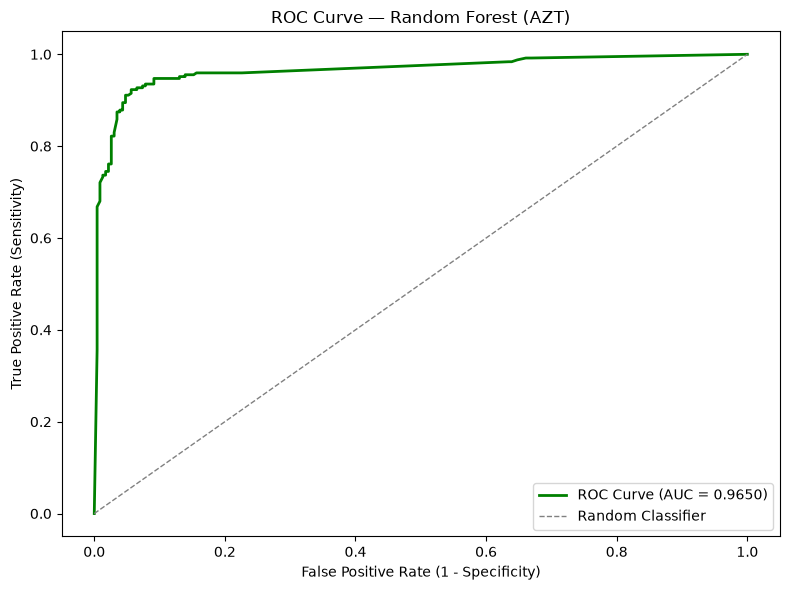

In [650]:
# 1. Print Precision, Recall, and F1-Score for each class
print("--- Classification Report ---")
print(classification_report(y_test_AZT, y_pred_rf))

# 2. Print Confusion Matrix (Shows True Positives, False Positives, etc.)
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test_AZT, y_pred_rf))
cm_rf = confusion_matrix(y_test_AZT, y_pred_rf)

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix - Random Forest (AZT)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Get and plot the ROC curve metrics
y_pred_proba_rf = rf_model.predict_proba(X_test_AZT)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test_AZT, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test_AZT, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC Curve (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Random Forest (AZT)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Support Vector Machine - AZT**

In [651]:
#Train and Test the SVM model
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train_AZT, y_train_AZT)
Y_pred_svm = svm_model.predict(X_test_AZT)

/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- SVM Test Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       230
           1       0.91      0.92      0.91       247

    accuracy                           0.91       477
   macro avg       0.91      0.91      0.91       477
weighted avg       0.91      0.91      0.91       477

--- SVM Test Confusion Matrix ---
[[207  23]
 [ 20 227]]


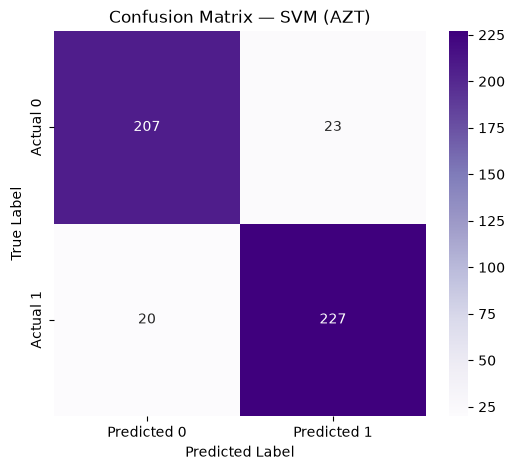

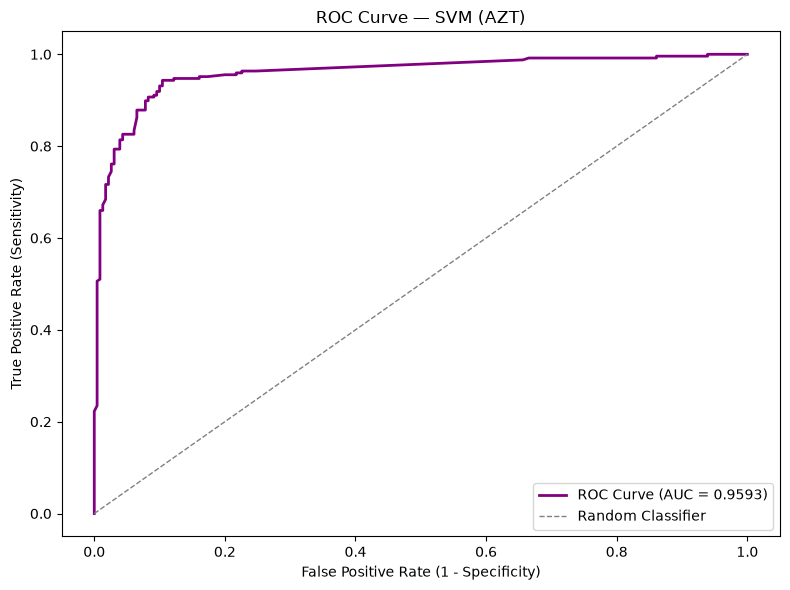

In [652]:
# 1. Generate predictions using the SVM model
y_pred_svm = svm_model.predict(X_test_AZT)
y_svm_proba = svm_model.predict_proba(X_test_AZT)[:, 1]

# 2. Print Confusion Matrix (Shows True Positives, False Positives, etc.)
print("--- SVM Test Classification Report ---")
print(classification_report(y_test_AZT, y_pred_svm))

# 3. Plot the confusion matrix
print("--- SVM Test Confusion Matrix ---")
print(confusion_matrix(y_test_AZT, y_pred_svm))
cm_svm = confusion_matrix(y_test_AZT, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix — SVM (AZT)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Get and plot the ROC curve metrics
y_proba_svm = svm_model.predict_proba(X_test_AZT)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test_AZT, y_proba_svm)
auc_svm = roc_auc_score(y_test_AZT, y_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'ROC Curve (AUC = {auc_svm:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — SVM (AZT)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**XGBoost - AZT**

In [653]:
# Train and test the XGBoost Model
Xgb_model = XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss')
Xgb_model.fit(X_train_AZT, y_train_AZT)
y_pred_Xgb = Xgb_model.predict(X_test_AZT)
y_train_AZT.shape

(1904,)

--- XGBoost Test Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       230
           1       0.94      0.92      0.93       247

    accuracy                           0.93       477
   macro avg       0.93      0.93      0.93       477
weighted avg       0.93      0.93      0.93       477

--- XGBoost Test Confusion Matrix ---
[[216  14]
 [ 20 227]]


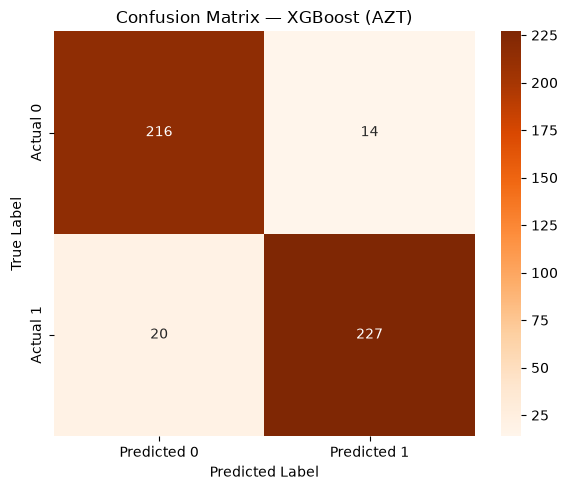

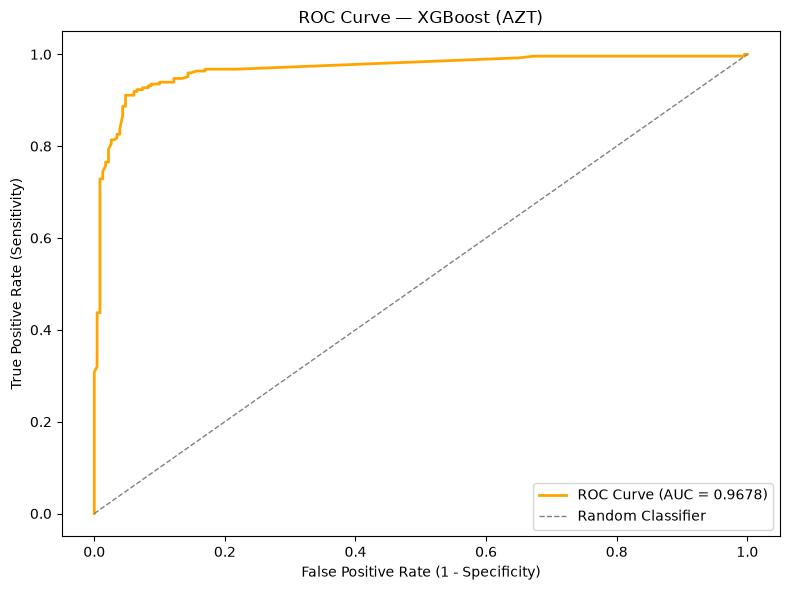

XGBoost ROC-AUC Score: 0.9678


In [654]:
# 1. Generate predictions and probabilities
y_pred_Xgb = Xgb_model.predict(X_test_AZT)
y_proba_Xgb = Xgb_model.predict_proba(X_test_AZT)[:, 1]

# 2. Print Confusion Matrix (Shows True Positives, False Positives, etc.)
print("--- XGBoost Test Classification Report ---")
print(classification_report(y_test_AZT, y_pred_Xgb))

print("--- XGBoost Test Confusion Matrix ---")
print(confusion_matrix(y_test_AZT, y_pred_Xgb))
cm_Xgb = confusion_matrix(y_test_AZT, y_pred_Xgb)

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_Xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix — XGBoost (AZT)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 4. Get and plot the ROC curve metrics
fpr_Xgb, tpr_Xgb, _ = roc_curve(y_test_AZT, y_proba_Xgb)
auc_Xgb = roc_auc_score(y_test_AZT, y_proba_Xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_Xgb, tpr_Xgb, color='orange', lw=2, label=f'ROC Curve (AUC = {auc_Xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — XGBoost (AZT)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"XGBoost ROC-AUC Score: {auc_Xgb:.4f}")

**Rank the AZT models according to the MCC**

In [655]:
#Import tool 
from sklearn.metrics import matthews_corrcoef

#Get the MCC for each model
mcc_lr = matthews_corrcoef(y_test_AZT, y_pred_lr)
mcc_rf = matthews_corrcoef(y_test_AZT, y_pred_rf)
mcc_svm = matthews_corrcoef(y_test_AZT, y_pred_svm)
mcc_xgb = matthews_corrcoef(y_test_AZT, y_pred_Xgb)

#Rank the models by MCC
mcc_scores = {"LR": (mcc_lr, lr_model),
              "RF": (mcc_rf, rf_model),
              "SVM": (mcc_svm, svm_model),
              "XGB": (mcc_xgb, Xgb_model),
              }

mcc_ranked = sorted(mcc_scores.items(), key=lambda x:x[1][0], reverse = True)

print("Model Ranking by MCC (AZT) ")
print(f"\n{'Rank':<6} {'Model':<22} {'MCC':>8}")
for rank, (name, (mcc, _)) in enumerate(mcc_ranked, start=1):
    print(f"{rank:<6} {name:<22} {mcc:>8.4f}")

#Save the best model into a pkl file
best_name, (best_mcc, best_model) = mcc_ranked[0]

joblib.dump(best_model, '/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_AZT.pkl')

print(f"\nBest model : {best_name}")

Model Ranking by MCC (AZT) 

Rank   Model                       MCC
1      RF                       0.8661
2      XGB                      0.8577
3      LR                       0.8368
4      SVM                      0.8195

Best model : RF


### Abacavir (ABC) Model Training

In [656]:
#Split the training data - 80/20
#Avoid the data leakage when the data is fitted by MLB
train_df_ABC, test_df_ABC = train_test_split(df_ABC, test_size=0.2, random_state=42,stratify = df_ABC['resistance'])
test_df_AZT.shape

(477, 6)

In [657]:
#Generate the Mutation matrix i.e the features
# Fit MLB on features training df and use transform on features test df
mlb.features = MultiLabelBinarizer(classes=relevant_mutations)
X_train_ABC = mlb.fit_transform(train_df_ABC['MutationListFiltered'])
X_test_ABC  = mlb.transform(test_df_ABC['MutationListFiltered'])
X_train_ABC.shape

(1784, 42)

In [658]:
#Extract the target
y_train_ABC = train_df_ABC["resistance"].values
y_test_ABC = test_df_ABC["resistance"].values

**Logistic Regression - ABC**

In [659]:
#Train the model and predict
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_ABC, y_train_ABC)
y_pred_lr = lr_model.predict(X_test_ABC)

Classification Report:


              precision    recall  f1-score   support

           0       0.91      0.87      0.89       270
           1       0.82      0.88      0.84       177

    accuracy                           0.87       447
   macro avg       0.87      0.87      0.87       447
weighted avg       0.88      0.87      0.87       447



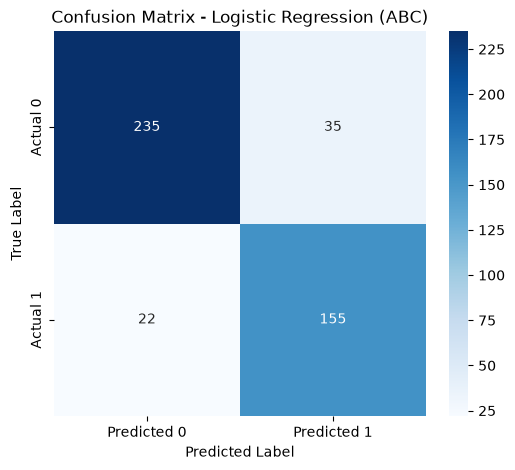

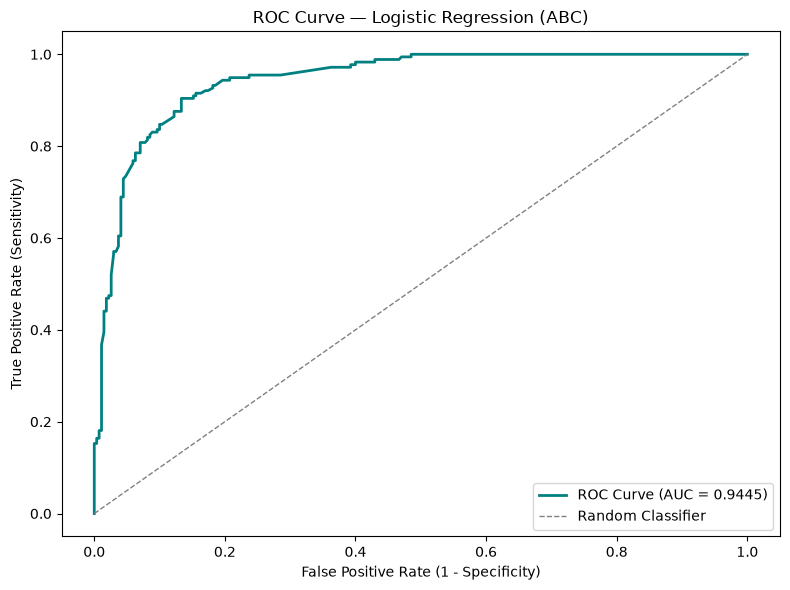

In [660]:
#LR Performance Metrics
# 1. Print the text-based classification report
print("Classification Report:")
print(classification_report(y_test_ABC, y_pred_lr))

# 2. Compute the confusion matrix values
cm_lr = confusion_matrix(y_test_ABC, y_pred_lr)

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix - Logistic Regression (ABC)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Get and plot the ROC curve metrics
y_pred_proba_lr = lr_model.predict_proba(X_test_ABC)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_ABC, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test_ABC, y_pred_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='teal', lw=2, label=f'ROC Curve (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Logistic Regression (ABC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Random Forest - ABC**

In [661]:
#Train and test the model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_ABC, y_train_ABC)
y_pred_rf = rf_model.predict(X_test_ABC)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       270
           1       0.78      0.90      0.84       177

    accuracy                           0.86       447
   macro avg       0.85      0.87      0.86       447
weighted avg       0.87      0.86      0.86       447

--- Confusion Matrix ---
[[224  46]
 [ 17 160]]


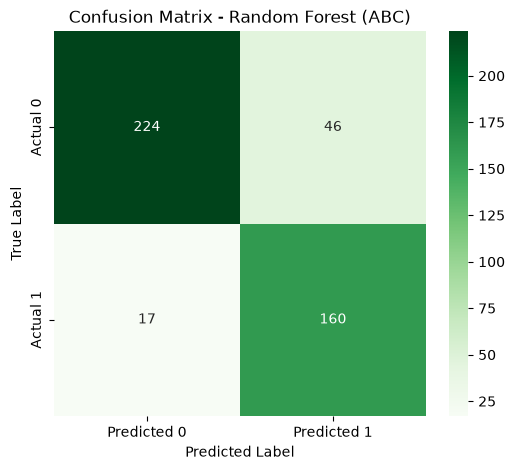

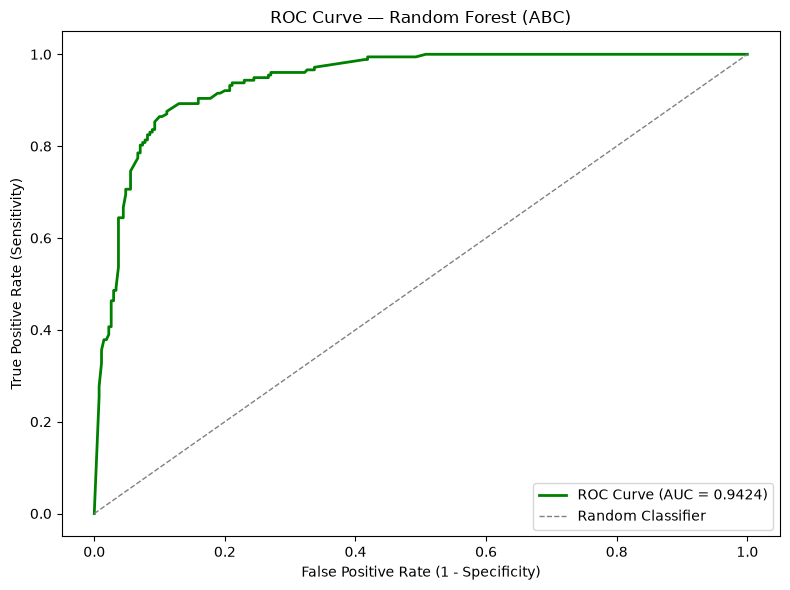

In [662]:
# 1. Print Precision, Recall, and F1-Score for each class
print("--- Classification Report ---")
print(classification_report(y_test_ABC, y_pred_rf))

# 2. Print Confusion Matrix (Shows True Positives, False Positives, etc.)
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test_ABC, y_pred_rf))
cm_rf = confusion_matrix(y_test_ABC, y_pred_rf)

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix - Random Forest (ABC)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Get and plot the ROC curve metrics
y_pred_proba_rf = rf_model.predict_proba(X_test_ABC)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test_ABC, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test_ABC, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC Curve (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Random Forest (ABC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Support Vector Machine - ABC**

In [663]:
#Train and Test the SVM model
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train_ABC, y_train_ABC)
Y_pred_svm = svm_model.predict(X_test_ABC)

/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- SVM Test Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       270
           1       0.84      0.84      0.84       177

    accuracy                           0.87       447
   macro avg       0.87      0.87      0.87       447
weighted avg       0.87      0.87      0.87       447

--- SVM Test Confusion Matrix ---
[[242  28]
 [ 28 149]]


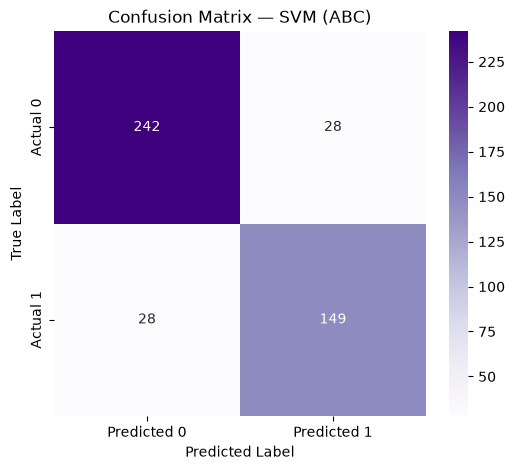

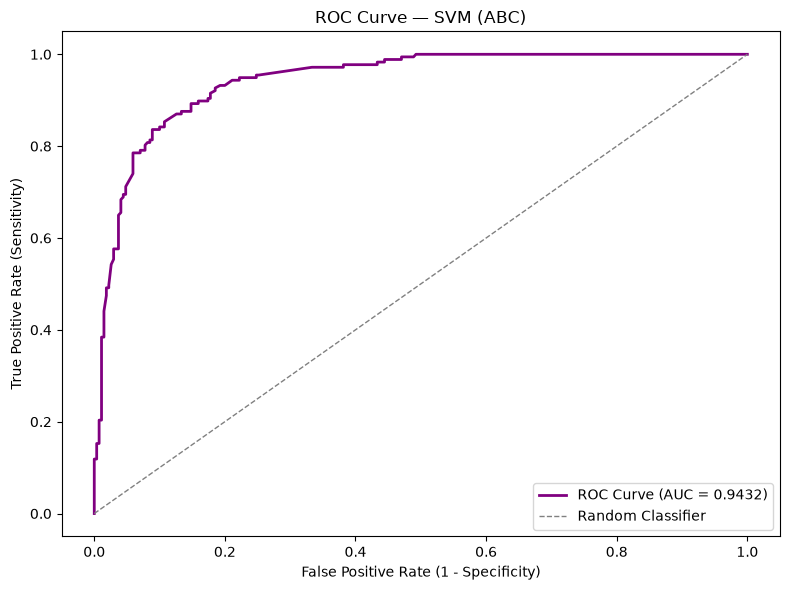

In [664]:
# 1. Generate predictions using the SVM model
y_pred_svm = svm_model.predict(X_test_ABC)
y_svm_proba = svm_model.predict_proba(X_test_ABC)[:, 1]

# 2. Print Confusion Matrix (Shows True Positives, False Positives, etc.)
print("--- SVM Test Classification Report ---")
print(classification_report(y_test_ABC, y_pred_svm))

# 3. Plot the confusion matrix
print("--- SVM Test Confusion Matrix ---")
print(confusion_matrix(y_test_ABC, y_pred_svm))
cm_svm = confusion_matrix(y_test_ABC, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix — SVM (ABC)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Get and plot the ROC curve metrics
y_proba_svm = svm_model.predict_proba(X_test_ABC)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test_ABC, y_proba_svm)
auc_svm = roc_auc_score(y_test_ABC, y_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'ROC Curve (AUC = {auc_svm:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — SVM (ABC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**XGBoost - ABC**

In [665]:
# Train and test the XGBoost Model
Xgb_model = XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss')
Xgb_model.fit(X_train_ABC, y_train_ABC)
y_pred_Xgb = Xgb_model.predict(X_test_ABC)
y_train_ABC.shape

(1784,)

--- XGBoost Test Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       270
           1       0.85      0.86      0.86       177

    accuracy                           0.89       447
   macro avg       0.88      0.88      0.88       447
weighted avg       0.89      0.89      0.89       447

--- XGBoost Test Confusion Matrix ---
[[243  27]
 [ 24 153]]


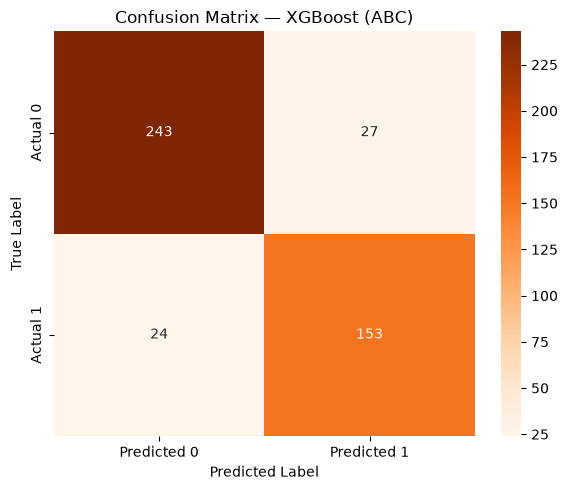

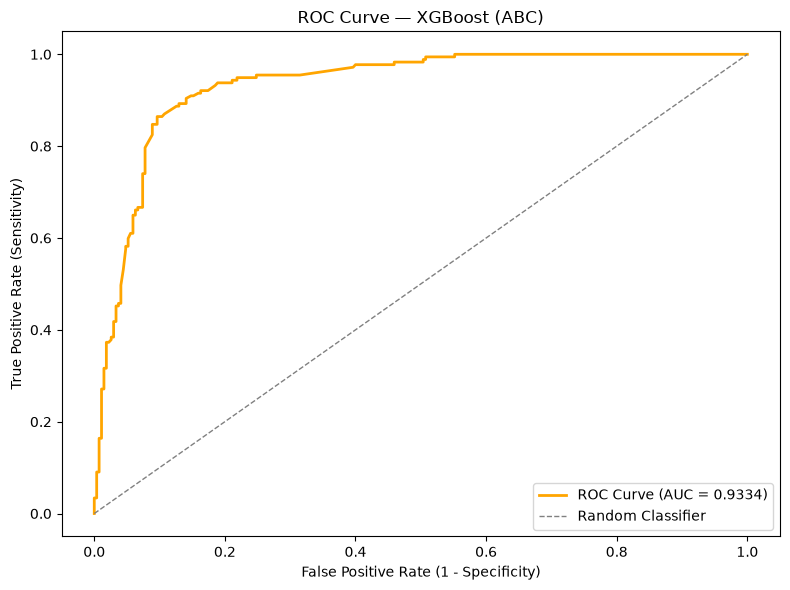

XGBoost ROC-AUC Score: 0.9334


In [666]:
# 1. Generate predictions and probabilities
y_pred_Xgb = Xgb_model.predict(X_test_ABC)
y_proba_Xgb = Xgb_model.predict_proba(X_test_ABC)[:, 1]

# 2. Print Confusion Matrix (Shows True Positives, False Positives, etc.)
print("--- XGBoost Test Classification Report ---")
print(classification_report(y_test_ABC, y_pred_Xgb))

print("--- XGBoost Test Confusion Matrix ---")
print(confusion_matrix(y_test_ABC, y_pred_Xgb))
cm_Xgb = confusion_matrix(y_test_ABC, y_pred_Xgb)

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_Xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix — XGBoost (ABC)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 4. Get and plot the ROC curve metrics
fpr_Xgb, tpr_Xgb, _ = roc_curve(y_test_ABC, y_proba_Xgb)
auc_Xgb = roc_auc_score(y_test_ABC, y_proba_Xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_Xgb, tpr_Xgb, color='orange', lw=2, label=f'ROC Curve (AUC = {auc_Xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — XGBoost (ABC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"XGBoost ROC-AUC Score: {auc_Xgb:.4f}")

**Rank the ABC best model according to MCC and save it into a pkl**

In [667]:
#Get the MCC for each model
mcc_lr = matthews_corrcoef(y_test_ABC, y_pred_lr)
mcc_rf = matthews_corrcoef(y_test_ABC, y_pred_rf)
mcc_svm = matthews_corrcoef(y_test_ABC, y_pred_svm)
mcc_xgb = matthews_corrcoef(y_test_ABC, y_pred_Xgb)

#Rank the models by MCC
mcc_scores = {"LR": (mcc_lr, lr_model),
              "RF": (mcc_rf, rf_model),
              "SVM": (mcc_svm, svm_model),
              "XGB": (mcc_xgb, Xgb_model),
              }

mcc_ranked = sorted(mcc_scores.items(), key=lambda x:x[1][0], reverse = True)

print("Model Ranking by MCC (ABC) ")
print(f"\n{'Rank':<6} {'Model':<22} {'MCC':>8}")
for rank, (name, (mcc, _)) in enumerate(mcc_ranked, start=1):
    print(f"{rank:<6} {name:<22} {mcc:>8.4f}")

#Save the best model into a pkl file
best_name, (best_mcc, best_model) = mcc_ranked[0]

joblib.dump(best_model, '/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_ABC.pkl')

print(f"\nBest model : {best_name}")

Model Ranking by MCC (ABC) 

Rank   Model                       MCC
1      XGB                      0.7623
2      SVM                      0.7381
3      LR                       0.7381
4      RF                       0.7197

Best model : XGB


### Integration and Deployment

In [668]:
## Cell 1: Load Models

import joblib

best_models = {
    "3TC": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_3TC.pkl"),
    "AZT": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_AZT.pkl"),
    "TDF": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_TDF.pkl"),
    "ABC": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_ABC.pkl")

}

best_models


/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


{'3TC': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...),
 'AZT': RandomForestClassifier(class_weight='balanced', random_state=42),
 'TDF': LogisticRegression(class_weight='balanced', l1_ratio=None, max_iter=1000,
                    penalty='l2', random_stat

In [669]:
#Loading feature columns
feature_columns = joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/feature_names.pkl")
# print(len(feature_columns))
feature_columns

['M184V',
 'M41L',
 'T215Y',
 'D67N',
 'L210W',
 'K70R',
 'K219Q',
 'T215F',
 'T69D',
 'E44D',
 'L74V',
 'S68G',
 'K219E',
 'L74I',
 'V75M',
 'M184MV',
 'A62V',
 'K65R',
 'K219N',
 'K219R',
 'D67G',
 'Q151M',
 'V75I',
 'D67DN',
 'E44A',
 'M41ML',
 'Y115F',
 'F77L',
 'L210LW',
 'K70KR',
 'F116Y',
 'L74LV',
 'L74LI',
 'V75T',
 'E44ED',
 'S68SG',
 'M184I',
 'A62AV',
 'K219KR',
 'K219KN',
 'T215D',
 'K70G']

In [670]:
# #Predict New Patients. for example 

# new_patient = pd.DataFrame(0,index=[0],columns=X.columns)

# new_patient["M184V"]=1

# new_patient["K65R"]=1

# new_patient["L74V"]=1

In [671]:
# test_mutation = ["M41L", "A62AV", "L74I", "M184V", "L210W", "T215Y",'Q151M']
test_mutation = ["M41L","A62AV","T215Y","K70R","L74V","K219Q","L210W"]
test_mutation2 = ["M41L"]

#### Predict Drug Resistance for 3TC

In [672]:
import pandas as pd

def predict_3TC(mutations, model, feature_columns):

    # Create empty mutation vector
    patient = pd.DataFrame( 0, index=[0], columns=feature_columns )

    # Encode mutations
    for mut in mutations:
        if mut in patient.columns:
            patient.loc[0, mut] = 1
        else:
            print(f"{mut} not found in training features.")

    # Predict
    pred = model.predict(patient)[0]
    prob = model.predict_proba(patient)[0,1]

    print("Mutations:", mutations)
    print("Prediction:",
          "Resistant" if pred else "Susceptible")
    print("Resistance probability:",
          round(prob,3))

    return patient


predict_3TC(test_mutation, best_models["3TC"], feature_columns)

Mutations: ['M41L', 'A62AV', 'T215Y', 'K70R', 'L74V', 'K219Q', 'L210W']
Prediction: Resistant
Resistance probability: 0.682


,M184V,M41L,T215Y,D67N,L210W,K70R,K219Q,T215F,T69D,E44D,...,L74LI,V75T,E44ED,S68SG,M184I,A62AV,K219KR,K219KN,T215D,K70G
0,0,1,1,0,1,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


#### Predict Drug Resistance for TDF

In [673]:
import pandas as pd

def predict_TDF(mutations, model, feature_columns):

    # Create empty mutation vector
    patient = pd.DataFrame( 0, index=[0], columns=feature_columns )

    # Encode mutations
    for mut in mutations:
        if mut in patient.columns:
            patient.loc[0, mut] = 1
        else:
            print(f"{mut} not found in training features.")

    # Predict
    pred = model.predict(patient)[0]
    prob = model.predict_proba(patient)[0,1]

    print("Mutations:", mutations)
    print("Prediction:",
          "Resistant" if pred else "Susceptible")
    print("Resistance probability:",round(prob,3))

    return patient

predict_TDF(test_mutation, best_models["TDF"], feature_columns)

Mutations: ['M41L', 'A62AV', 'T215Y', 'K70R', 'L74V', 'K219Q', 'L210W']
Prediction: Resistant
Resistance probability: 0.504


/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,M184V,M41L,T215Y,D67N,L210W,K70R,K219Q,T215F,T69D,E44D,...,L74LI,V75T,E44ED,S68SG,M184I,A62AV,K219KR,K219KN,T215D,K70G
0,0,1,1,0,1,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


#### Predict Drug Resistance for AZT

In [674]:
import pandas as pd

def predict_AZT(mutations, model, feature_columns):

    # Create empty mutation vector
    patient = pd.DataFrame( 0, index=[0], columns=feature_columns )

    # Encode mutations
    for mut in mutations:
        if mut in patient.columns:
            patient.loc[0, mut] = 1
        else:
            print(f"{mut} not found in training features.")

    # Predict
    pred = model.predict(patient)[0]
    prob = model.predict_proba(patient)[0,1]

    print("Mutations:", mutations)
    print("Prediction:", "Resistant" if pred else "Susceptible")
    print("Resistance probability:",round(prob,3))

    return patient

predict_AZT(test_mutation, best_models["AZT"], feature_columns)

Mutations: ['M41L', 'A62AV', 'T215Y', 'K70R', 'L74V', 'K219Q', 'L210W']
Prediction: Resistant
Resistance probability: 0.87


/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,M184V,M41L,T215Y,D67N,L210W,K70R,K219Q,T215F,T69D,E44D,...,L74LI,V75T,E44ED,S68SG,M184I,A62AV,K219KR,K219KN,T215D,K70G
0,0,1,1,0,1,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


### Predict Drug Resistance for ABC

In [675]:
import pandas as pd

def predict_ABC(mutations, model, feature_columns):

    # Create empty mutation vector
    patient = pd.DataFrame( 0, index=[0], columns=feature_columns )

    # Encode mutations
    for mut in mutations:
        if mut in patient.columns:
            patient.loc[0, mut] = 1
        else:
            print(f"{mut} not found in training features.")

    # Predict
    pred = model.predict(patient)[0]
    prob = model.predict_proba(patient)[0,1]

    print("Mutations:", mutations)
    print("Prediction:", "Resistant" if pred else "Susceptible")
    print("Resistance probability:",round(prob,3))

    return patient

predict_ABC(test_mutation, best_models["ABC"], feature_columns)

Mutations: ['M41L', 'A62AV', 'T215Y', 'K70R', 'L74V', 'K219Q', 'L210W']
Prediction: Resistant
Resistance probability: 0.791


,M184V,M41L,T215Y,D67N,L210W,K70R,K219Q,T215F,T69D,E44D,...,L74LI,V75T,E44ED,S68SG,M184I,A62AV,K219KR,K219KN,T215D,K70G
0,0,1,1,0,1,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


### DawaFit Container

In [676]:
import pandas as pd
import joblib

# Load everything models and feature columns
best_models = best_models = {
    "3TC": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_3TC.pkl"),
    "AZT": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_AZT.pkl"),
    "TDF": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_TDF.pkl"),
    "ABC": joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/best_model_ABC.pkl")

}

feature_columns = joblib.load("/home/noel/Desktop/Eneza/eneza_project/HIV-drug-resistance-prediction-from-viral-sequences/DawaFit/models/feature_names.pkl")


# Prediction Pipeline

def MutationPredictor(mutations, models, feature_columns):

    # Create empty patient feature vector
    patient = pd.DataFrame(0,index=[0],columns=feature_columns)

    # Encode mutations
    unknown_mutations = []

    for mut in mutations:
        if mut in feature_columns:
            patient.loc[0, mut] = 1
        else:
            unknown_mutations.append(mut)

    # Predict resistance for every drug
    results = []

    for drug, model in models.items():

        pred = model.predict(patient)[0]
        prob = model.predict_proba(patient)[0, 1]

        results.append({
            "Drug": drug,
            "Prediction": "Resistant" if pred == 1 else "Susceptible",
            "Resistance Probability": round(prob, 3)
        })

    results = pd.DataFrame(results)

    if unknown_mutations:
        print("Ignored mutations:", ", ".join(unknown_mutations))

    results = pd.DataFrame(results)

    recommended = results.loc[results["Prediction"] == "Susceptible","Drug"].tolist()
    avoid = results.loc[results["Prediction"] == "Resistant", "Drug"].tolist()

    # Print summary
    print("=" * 50)
    print("Patient mutations:", ", ".join(mutations))

    if unknown_mutations:
        print("Ignored mutations:", ", ".join(unknown_mutations))

    print("\nPrediction Results")
    print(results)

    print("\nRecommended drugs:", ", ".join(recommended))
    print("Avoid:", ", ".join(avoid))

    return results, recommended, avoid
       

/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [677]:
# Try Container (Dry Run)

MutationPredictor(test_mutation, best_models, feature_columns)

Patient mutations: M41L, A62AV, T215Y, K70R, L74V, K219Q, L210W

Prediction Results
  Drug Prediction  Resistance Probability
0  3TC  Resistant                   0.682
1  AZT  Resistant                   0.870
2  TDF  Resistant                   0.504
3  ABC  Resistant                   0.791

Recommended drugs: 
Avoid: 3TC, AZT, TDF, ABC


/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/noel/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


(  Drug Prediction  Resistance Probability
 0  3TC  Resistant                   0.682
 1  AZT  Resistant                   0.870
 2  TDF  Resistant                   0.504
 3  ABC  Resistant                   0.791,
 [],
 ['3TC', 'AZT', 'TDF', 'ABC'])

### Treatment Recommendation